## Version 1

In [1]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.feature_selection import SelectKBest, f_regression, SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR # Example alternative

# Helper for timing
from contextlib import contextmanager

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

In [2]:


# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files:
# - `guided_dataset_X.npy`: Training/Validation sEMG data (sessions, electrodes, time)
# - `guided_dataset_y.npy`: Training/Validation joint angle data (sessions, joints, time)
# - `guided_testset_X.npy`: Test sEMG data (sessions, windows, electrodes, time_in_window) - *Note: We'll handle the test set structure later when predicting for the competition.*

# %%
# File paths (assuming data is in the same directory as the notebook)
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy" # We won't use this heavily until Objective 7

# Load the training/validation data
X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)

# Load the test data structure description (we need shape info)
X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r') # Use mmap_mode for large files if needed

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}") # (session, electrode, time) -> (5, 8, 230000)
print(f"y_train_val_raw: {y_train_val_raw.shape}") # (session, joint, time) -> (5, 51, 230000)
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}") # (session, window_idx, electrode, time_in_window) -> (5, 332, 8, 500)

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")


Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51


In [3]:


# %% [markdown]
# ## 2. (Optional) Signal Filtering
#
# *This step is optional but recommended.* Common filtering includes band-pass filtering (e.g., 20-450 Hz) to remove noise and DC offset removal. For simplicity in this initial baseline, we will **skip explicit filtering**. However, note that some features (like ZC) might be sensitive to baseline wander if not removed. Normalization (like StandardScaler later) helps mitigate some scaling issues.
#
# *If you wanted to add filtering, you would apply it here to `X_train_val_raw` before windowing.*
# ```python
# # Example (requires scipy):
from scipy.signal import butter, filtfilt
# #
def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs
     low = lowcut / nyq
     high = highcut / nyq
     b, a = butter(order, [low, high], btype='band')
     return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
     b, a = butter_bandpass(lowcut, highcut, fs, order=order)
     # Apply filter along the time axis (axis=-1)
     y = filtfilt(b, a, data, axis=-1)
     return y

FS = 1024 # Sampling frequency from documentation
LOWCUT = 20
HIGHCUT = 450

X_train_val_filtered = np.zeros_like(X_train_val_raw)
for i in range(N_SESSIONS_TRAIN_VAL):
     # Remove DC offset (mean) per channel
     dc_removed = X_train_val_raw[i] - np.mean(X_train_val_raw[i], axis=-1, keepdims=True)
     # Apply bandpass filter
     X_train_val_filtered[i] = bandpass_filter(dc_removed, LOWCUT, HIGHCUT, FS)

X_train_val_to_window = X_train_val_filtered
print("Applied DC offset removal and bandpass filtering.")
# ```
# For now, we proceed without filtering:

# %%
## X_train_val_to_window = X_train_val_raw
## print("Skipping explicit signal filtering for this baseline.")

Applied DC offset removal and bandpass filtering.


In [4]:


# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# We need to segment the continuous sEMG and joint angle data into overlapping windows.
# - Window size `k = 500` samples (as specified).
# - Overlap: We choose an overlap percentage (e.g., 50% or 75%). A higher overlap increases the dataset size but also computational cost. Let's start with 50%.
# - Target `y` for a window: The joint angles at the **end** of the corresponding sEMG window `[t-k+1, t]` will be predicted. So, the target `y` for the window ending at time `t` is `y[:, :, t]`.

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.50 # Start with 50%

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step == 0:
    raise ValueError("Overlap percentage cannot be 100%")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# %%
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    """
    Creates overlapping windows for EMG (X) and corresponding target joint angles (y).

    Args:
        X_raw (np.ndarray): Raw EMG data (n_sessions, n_electrodes, n_timepoints).
        y_raw (np.ndarray): Raw joint angle data (n_sessions, n_joints, n_timepoints).
        window_size (int): The size of each window (k).
        step (int): The step size between the start of consecutive windows.

    Returns:
        tuple: (X_windowed, y_windowed, groups)
            X_windowed (np.ndarray): Windowed EMG data (n_windows, n_electrodes, window_size).
            y_windowed (np.ndarray): Corresponding target joint angles (n_windows, n_joints).
            groups (np.ndarray): Group label (session index) for each window (n_windows,).
    """
    n_sessions = X_raw.shape[0]
    n_electrodes = X_raw.shape[1]
    n_timepoints = X_raw.shape[2]
    n_joints = y_raw.shape[1]

    X_windowed_list = []
    y_windowed_list = []
    groups_list = []

    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx] # (n_electrodes, n_timepoints)
        session_y = y_raw[session_idx] # (n_joints, n_timepoints)

        start_indices = np.arange(0, n_timepoints - window_size + 1, step)

        for start_idx in start_indices:
            end_idx = start_idx + window_size
            # EMG window: from start_idx to end_idx (exclusive of end_idx if numpy slicing)
            # Adjusting to include start_idx to end_idx-1, which is 'window_size' points
            window_X = session_X[:, start_idx:end_idx]

            # Target y: joint angles at the *end* of the window (time index end_idx - 1)
            target_y = session_y[:, end_idx - 1]

            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx) # Store the session index for GroupKFold

        print(f"Session {session_idx}: Created {len(start_indices)} windows.")

    X_windowed = np.stack(X_windowed_list) # Shape: (total_windows, n_electrodes, window_size)
    y_windowed = np.stack(y_windowed_list) # Shape: (total_windows, n_joints)
    groups = np.array(groups_list)          # Shape: (total_windows,)

    return X_windowed, y_windowed, groups

# %%
# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

print("\nWindowed Data Shapes:")
print(f"X_windowed: {X_windowed.shape}")
print(f"y_windowed: {y_windowed.shape}")
print(f"Groups: {groups.shape}")
print(f"Unique groups (sessions): {np.unique(groups)}")



Window Size (k): 500
Overlap: 50%
Step Size: 250
Creating overlapping windows...
Session 0: Created 919 windows.
Session 1: Created 919 windows.
Session 2: Created 919 windows.
Session 3: Created 919 windows.
Session 4: Created 919 windows.
Creating overlapping windows done in 0.18 seconds.


Windowed Data Shapes:
X_windowed: (4595, 8, 500)
y_windowed: (4595, 51)
Groups: (4595,)
Unique groups (sessions): [0 1 2 3 4]


In [5]:

# %% [markdown]
# ## 4. Custom Feature Extractor (Baseline - Objective 4)
#
# Create a Scikit-learn compatible transformer (`BaseEstimator`, `TransformerMixin`) to extract the time-domain features specified in Table 1, plus the requested WL (Waveform Length) and SSC (Slope Sign Changes).
#
# **Features:**
# 1.  **MAV** (Mean Absolute Value)
# 2.  **RMS** (Root Mean Square)
# 3.  **Variance** (Var)
# 4.  **STD** (Standard Deviation)
# 5.  **ZC** (Zero Crossing) - Requires a threshold, typically near zero.
# 6.  **MPR** (Myopulse Percentage Rate) - Requires a threshold `σ`. We'll define `σ` as the standard deviation of the signal *within the window*.
# 7.  **WL** (Waveform Length) - Sum of absolute differences between consecutive samples.
# 8.  **SSC** (Slope Sign Changes) - Count of times the slope of the signal changes sign. Requires a threshold to avoid noise.

# %%
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extracts time-domain features from EMG windows.

    Args:
        zc_threshold (float): Threshold for detecting zero crossings.
        ssc_threshold (float): Threshold for detecting slope sign changes.
        selected_features (list, optional): List of feature names to compute.
                                            Defaults to all defined features.
    """
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None):
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.all_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC']
        if selected_features is None:
            self.selected_features = self.all_feature_names
        else:
            # Validate selected features
            if not all(f in self.all_feature_names for f in selected_features):
                raise ValueError(f"Invalid feature names in selected_features. "
                                 f"Allowed features: {self.all_feature_names}")
            self.selected_features = selected_features

    def fit(self, X, y=None):
        # This transformer doesn't need fitting
        return self

    def transform(self, X):
        """
        Transforms the windowed EMG data into features.

        Args:
            X (np.ndarray): Windowed EMG data (n_windows, n_electrodes, window_size).

        Returns:
            np.ndarray: Feature matrix (n_windows, n_electrodes * n_selected_features).
        """
        n_windows, n_electrodes, window_size = X.shape
        n_selected = len(self.selected_features)
        features = np.zeros((n_windows, n_electrodes * n_selected))

        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                channel_features = []

                # Calculate basic stats needed for multiple features
                mav = np.mean(np.abs(channel_data))
                rms = np.sqrt(np.mean(channel_data**2))
                var = np.var(channel_data)
                std = np.sqrt(var) # Or np.std(channel_data)

                if 'MAV' in self.selected_features:
                    channel_features.append(mav)
                if 'RMS' in self.selected_features:
                    channel_features.append(rms)
                if 'Var' in self.selected_features:
                    channel_features.append(var)
                if 'STD' in self.selected_features:
                    channel_features.append(std)

                # Zero Crossing (ZC)
                if 'ZC' in self.selected_features:
                    zc = np.sum(np.diff(np.sign(channel_data - self.zc_threshold)) != 0) / 2
                    # Alternative: count sign changes around 0 after removing mean?
                    # zc = np.sum(np.abs(np.diff(np.sign(channel_data))) > 1) # More robust maybe
                    # Let's use a common definition checking crossing threshold
                    zc_count = 0
                    for k in range(window_size - 1):
                         if ((channel_data[k] > self.zc_threshold and channel_data[k+1] < self.zc_threshold) or \
                            (channel_data[k] < self.zc_threshold and channel_data[k+1] > self.zc_threshold)):
                             #and np.abs(channel_data[k] - channel_data[k+1]) >= self.zc_threshold * 2): # Optional: ensure it's not just noise around threshold
                            zc_count += 1
                    channel_features.append(zc_count)

                # Myopulse Percentage Rate (MPR)
                if 'MPR' in self.selected_features:
                    # Use window's STD as threshold σ, avoid division by zero if std is ~0
                    threshold_mpr = std if std > 1e-9 else 1e-9
                    mpr = np.mean(np.abs(channel_data) > threshold_mpr) # Rate is mean of indicator
                    channel_features.append(mpr)

                # Waveform Length (WL)
                if 'WL' in self.selected_features:
                    wl = np.sum(np.abs(np.diff(channel_data)))
                    channel_features.append(wl)

                # Slope Sign Changes (SSC)
                if 'SSC' in self.selected_features:
                    diff_sig = np.diff(channel_data)
                    ssc_count = 0
                    for k in range(len(diff_sig) - 1):
                        if ((diff_sig[k] > self.ssc_threshold and diff_sig[k+1] < -self.ssc_threshold) or \
                           (diff_sig[k] < -self.ssc_threshold and diff_sig[k+1] > self.ssc_threshold)):
                             ssc_count += 1
                    # Alternative from user prompt (might be sensitive):
                    # diff1 = np.diff(channel_data)
                    # diff2 = np.diff(channel_data, n=2)
                    # ssc = np.sum((diff1[:-1] * diff2) > 0) # This definition seems different from literature? Checking sign *product*
                    # Let's stick to the common definition counting sign changes with threshold
                    channel_features.append(ssc_count)

                window_features.extend(channel_features) # Add features for this channel

            features[i, :] = window_features # Assign features for this window

        # Handle potential NaNs or Infs that might arise from edge cases
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)

        return features

    def get_feature_names_out(self, input_features=None):
        """Returns feature names based on electrodes and selected features."""
        feature_names = []
        for j in range(N_ELECTRODES): # Assumes N_ELECTRODES is accessible or passed
            for feature_name in self.selected_features:
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return feature_names

# %%
# Test the feature extractor
with timer("Testing Feature Extractor"):
    feature_extractor = EMGFeatureExtractor()
    X_features = feature_extractor.fit_transform(X_windowed)

print("Feature Matrix Shape:")
print(f"X_features: {X_features.shape}") # Should be (n_windows, n_electrodes * n_features)

# Verify number of features
n_expected_features = N_ELECTRODES * len(feature_extractor.selected_features)
print(f"Expected number of features per window: {n_expected_features}")
assert X_features.shape[1] == n_expected_features, "Feature dimension mismatch!"

# Get feature names
feature_names = feature_extractor.get_feature_names_out()
print(f"\nGenerated {len(feature_names)} feature names. Examples:")
print(feature_names[:5])
print(feature_names[-5:])



Testing Feature Extractor...
Testing Feature Extractor done in 67.94 seconds.

Feature Matrix Shape:
X_features: (4595, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples:
['Elec1_MAV', 'Elec1_RMS', 'Elec1_Var', 'Elec1_STD', 'Elec1_ZC']
['Elec8_STD', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL', 'Elec8_SSC']


Using GroupKFold with 5 splits (Leave-One-Session-Out).
Group labels for CV: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0] ...


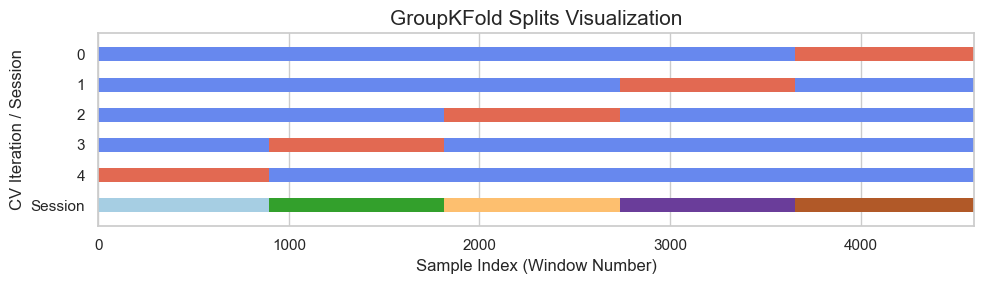

In [6]:

# %% [markdown]
# ## 5. Cross-Validation Strategy (Objective 3)
#
# **Strategy:** Use `GroupKFold` with session IDs as groups.
#
# **Justification:**
# 1.  **Prevents Data Leakage:** Ensures that all data (all windows) from a single recording session are either entirely in the training set or entirely in the validation set for each fold. This is crucial because data points within the same session are likely correlated due to consistent sensor placement, participant state, and potentially similar movement patterns performed close in time. Simple KFold or ShuffleSplit would randomly mix windows from the same session into train and validation, leading to overly optimistic performance estimates because the model would be validated on data very similar (temporally close or from the same recording setup) to data it was trained on.
# 2.  **Simulates Realistic Scenario:** In a real-world application, a model trained on sessions from one day (or set of conditions) might need to generalize to a new session on another day. `GroupKFold` mimics this by testing the model's ability to generalize across sessions.
# 3.  **Uses All Data:** Like KFold, it allows using all data for both training and validation across the different folds.
#
# We have 5 sessions, so `n_splits=5` is a natural choice for `GroupKFold`, leading to a Leave-One-Session-Out cross-validation.

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)

print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")
print("Group labels for CV:", groups[:20], "...") # Show example group labels

# Visualize the splits (optional but good for understanding)
def plot_cv_indices(cv, X, y, group, n_splits):
    """Creates a sample plot for training/validation indices"""
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired
    cmap_cv = plt.cm.coolwarm
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        # fill the train/test groups with colors
        indices = np.array([np.nan] * len(X))
        indices[test_idx] = 1
        indices[train_idx] = 0
        # Visualize the results
        ax.scatter(range(len(indices)), [i + .5] * len(indices),
                   c=indices, marker='_', lw=10, cmap=cmap_cv,
                   vmin=-.2, vmax=1.2)

    # Plot the data classes at the end
    ax.scatter(range(len(X)), [i + 1.5] * len(X),
               c=group, marker='_', lw=10, cmap=cmap_data)

    # Formatting
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels,
           xlabel='Sample Index (Window Number)', ylabel="CV Iteration / Session",
           ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15)
    plt.tight_layout()
    plt.show()

# Plot for our setup
plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)

# %% [markdown]
# The plot shows that for each CV iteration (rows 0-4), one entire session (indicated by color in the bottom row 'Session') is held out as the validation set (red), while the other sessions are used for training (blue). This confirms our strategy prevents session-based data leakage.


Cross-validating Ridge...
Cross-validating Ridge done in 146.59 seconds.

Cross-validating RandomForest...
Cross-validating RandomForest done in 176.44 seconds.


Cross-Validation Performance Results:

--- Ridge ---
  RMSE: 7.3009 +/- 0.5578
  NMSE: 0.2661 +/- 0.0472
  R2 Score: 0.5816 +/- 0.0848
  Avg Fit Time: 85.74s
  Avg Score Time: 26.47s

--- RandomForest ---
  RMSE: 4.5513 +/- 0.7433
  NMSE: 0.1056 +/- 0.0380
  R2 Score: 0.7103 +/- 0.0752
  Avg Fit Time: 126.56s
  Avg Score Time: 35.49s

--- Summary Table ---
       Model  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge     7.3009    0.5578     0.2661    0.0472   0.5816  0.0848  85.7377
RandomForest     4.5513    0.7433     0.1056    0.0380   0.7103  0.0752 126.5562
Extracting features and scaling for Importance Analysis...
Extracting features and scaling for Importance Analysis done in 57.02 seconds.

Training RandomForest on full data for Importance Analysis...
Training RandomForest on full data

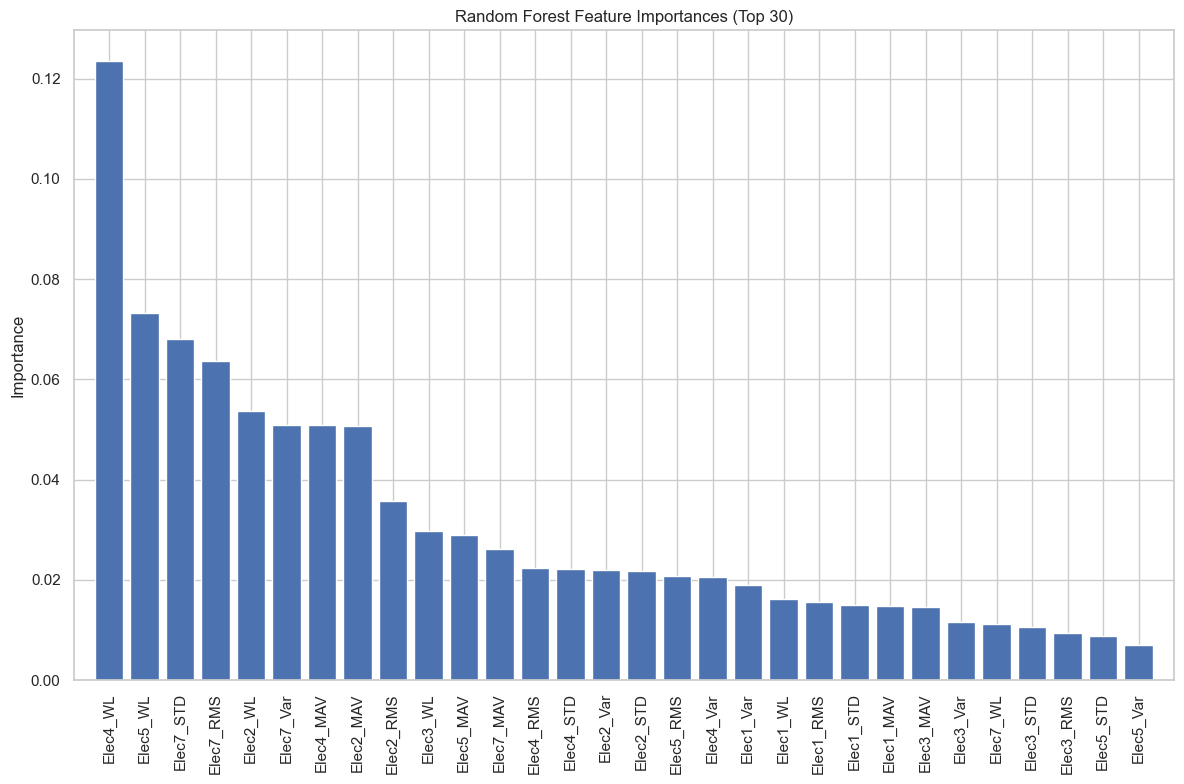

In [7]:

# %% [markdown]
# ## 6. Baseline Model Training and Evaluation (Objective 4)
#
# We will:
# 1.  Define performance metrics: RMSE and NMSE.
# 2.  Select two regression models (e.g., `Ridge`, `RandomForestRegressor`).
# 3.  Create a pipeline: `EMGFeatureExtractor` -> `StandardScaler` -> `Regressor`.
# 4.  Evaluate models using `cross_validate` with our `GroupKFold` strategy.
# 5.  Compare performance and feature importances (for RF).

# %%
# Define Performance Metrics

def root_mean_squared_error(y_true, y_pred):
    """Calculate RMSE across all dimensions."""
    return np.sqrt(mean_squared_error(y_true, y_pred))

def normalized_mean_squared_error(y_true, y_pred):
    """Calculate NMSE across all dimensions."""
    # Ensure y_true and y_pred are numpy arrays
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape != y_pred.shape:
        raise ValueError("Input arrays y_true and y_pred must have the same shape.")
    if y_true.ndim == 1: # Handle case if only one joint is predicted (unlikely here)
        y_true = y_true.reshape(-1, 1)
        y_pred = y_pred.reshape(-1, 1)

    # Calculate numerator: MSE summed over all dimensions and samples
    numerator = np.sum((y_true - y_pred)**2)

    # Calculate denominator: Variance summed over all dimensions and samples
    # Mean of each joint angle across all test observations
    mean_y_true_per_joint = np.mean(y_true, axis=0) # Shape (n_joints,)
    # Denominator uses variance relative to the mean of each joint angle
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)

    if denominator == 0:
        # Handle case where true values are constant
        return np.inf if numerator > 1e-9 else 0.0

    return numerator / denominator

# Create scorers for cross-validation
scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score) # R2 score is also informative
}

# %%
# Select Models
model_ridge = Ridge(alpha=1.0) # Basic regularized linear model
model_rf = RandomForestRegressor(
    n_estimators=100, # Number of trees
    max_depth=15,     # Limit tree depth to prevent overfitting
    n_jobs=-1,        # Use all available CPU cores
    random_state=42,  # For reproducibility
    max_features=0.33 # Consider only a subset of features for each split
)

models_to_evaluate = {
    "Ridge": model_ridge,
    "RandomForest": model_rf
}

# %%
# Evaluate models using Cross-Validation
cv_results = {}

for model_name, model in models_to_evaluate.items():
    with timer(f"Cross-validating {model_name}"):
        # Create the full pipeline for this model
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Use default features for now
            ('scaling', StandardScaler()),
            ('regression', model)
        ])

        # Perform cross-validation
        # Pass the *original* windowed data (X_windowed) here.
        # The pipeline handles feature extraction and scaling internally for each fold.
        scores = cross_validate(
            pipeline,
            X_windowed,         # Input to the pipeline
            y_windowed,         # Target variable
            groups=groups,      # Group labels for GroupKFold
            cv=cv_strategy,     # The GroupKFold object
            scoring=scorers,
            n_jobs=-1,          # Parallelize CV folds if possible
            return_train_score=False # We mainly care about validation scores
        )
        cv_results[model_name] = scores

# %%
# Display CV Results
print("\nCross-Validation Performance Results:")

results_summary = []
for model_name, scores in cv_results.items():
    mean_rmse = -np.mean(scores['test_rmse']) # Negated because scorer is loss
    std_rmse = np.std(scores['test_rmse'])
    mean_nmse = -np.mean(scores['test_nmse'])
    std_nmse = np.std(scores['test_nmse'])
    mean_r2 = np.mean(scores['test_r2'])
    std_r2 = np.std(scores['test_r2'])
    fit_time_mean = np.mean(scores['fit_time'])
    score_time_mean = np.mean(scores['score_time'])

    print(f"\n--- {model_name} ---")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
    print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
    print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
    print(f"  Avg Score Time: {score_time_mean:.2f}s")

    results_summary.append({
        'Model': model_name,
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

# Create a DataFrame for easier comparison
results_df = pd.DataFrame(results_summary)
print("\n--- Summary Table ---")
print(results_df.to_string(index=False, float_format="%.4f"))

# %% [markdown]
# **Interpretation:**
# - Compare the mean RMSE and NMSE values. Lower is better.
# - Compare the mean R2 scores. Higher is better (closer to 1).
# - Note the standard deviations - a high standard deviation indicates inconsistent performance across sessions.
# - Consider the fit times. Random Forest is typically slower to train than Ridge.
# - Based on these results, select the potentially "best" baseline model so far (e.g., the one with the lowest RMSE or highest R2, depending on your priority).

# %%
# Feature Importances (for Random Forest)

# We need to train the RF model once on the full training data
# (or one fold's training data) to get importances easily.
# Let's create the feature extraction + scaling steps separately for this.

# Create pipeline steps manually
feature_pipeline = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

# Fit and transform the full training data
with timer("Extracting features and scaling for Importance Analysis"):
    X_features_scaled = feature_pipeline.fit_transform(X_windowed, y_windowed)
    # Get feature names AFTER scaling (they remain the same)
    feature_names = feature_pipeline.named_steps['feature_extraction'].get_feature_names_out()

# Train the Random Forest model on the scaled features
with timer("Training RandomForest on full data for Importance Analysis"):
    model_rf.fit(X_features_scaled, y_windowed)

# Get feature importances
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1] # Sort features by importance (descending)

# Print the feature ranking
print("\nRandom Forest Feature Importances (Top 30):")
n_top_features = 30
for i in range(min(n_top_features, len(importances))):
    print(f"{i + 1}. Feature: {feature_names[indices[i]]} ({importances[indices[i]]:.4f})")

# Plot feature importances
plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30)")
plt.bar(range(min(n_top_features, len(importances))), importances[indices[:n_top_features]], align='center')
plt.xticks(range(min(n_top_features, len(importances))), [feature_names[i] for i in indices[:n_top_features]], rotation=90)
plt.xlim([-1, min(n_top_features, len(importances))])
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

# %% [markdown]
# **Interpretation of Feature Importances:**
# - Identify which features (and from which electrodes) are most influential for the Random Forest model.
# - Look for patterns: Are certain feature types (e.g., RMS, MAV) generally more important? Are specific electrode locations consistently ranked high? This can provide insights into the underlying EMG signals and muscle activity related to the gestures.


In [8]:
# %% [markdown]
# ## 7. Feature Selection (Objective 4)
#
# Perform feature selection to find the optimal subset of features that minimizes RMSE. We'll use `SequentialFeatureSelector` (SFS) which is generally more robust than `SelectKBest` but slower. We will use the faster Ridge model as the estimator within SFS for efficiency.
#
# *Note: SFS can be computationally expensive, especially with many features and cross-validation.* We might run it on a subset of data or limit the number of features to select if needed. For this dataset size, it might take some time.
#
# **Important:** We need to enable metadata routing for SFS to correctly pass the `groups` information to the internal `GroupKFold` cross-validator.

# %%
from sklearn import set_config # Import set_config
from sklearn.feature_selection import SequentialFeatureSelector # Already imported but good practice if separate cell

# Enable metadata routing - This allows passing 'groups' through .fit()
set_config(enable_metadata_routing=True)

# Configure SFS
# We use the Ridge model as it's faster for the internal CV loops of SFS
# We use our GroupKFold CV strategy inside SFS
sfs = SequentialFeatureSelector(
    estimator=Ridge(alpha=1.0), # Faster estimator for SFS
    n_features_to_select='auto', # Automatically find the best number of features ('best' based on CV score plateau)
    # Alternatively, set a fixed number: n_features_to_select=30
    # Or set a fraction: n_features_to_select=0.5 (select 50% of features)
    tol=None, # Set a tolerance if using 'auto' to stop when score improvement is less than tol
    direction='forward', # Start with 0 features and add one by one
    scoring=scorers['rmse'], # Use RMSE (negative RMSE, as scorer needs higher=better)
    cv=cv_strategy,       # Use our GroupKFold strategy
    n_jobs=-1             # Use all cores
)

# We need the scaled features computed earlier (X_features_scaled)
with timer("Performing Sequential Feature Selection (SFS)"):
    # Now, passing 'groups' is explicitly supported because metadata routing is enabled.
    # SFS will internally pass 'groups' to cv_strategy.split() when needed.
    sfs.fit(X_features_scaled, y_windowed, groups=groups)

# Optional: Disable metadata routing afterwards if it interferes elsewhere,
# though it's generally fine to leave it enabled.
# set_config(enable_metadata_routing=False) # Reset to default if needed

# %%
# Get selected features
selected_feature_indices = sfs.get_support(indices=True)

# Check if feature_names list is populated correctly
if 'feature_names' not in locals() or len(feature_names) != X_features_scaled.shape[1]:
     # Attempt to regenerate feature names if they weren't generated correctly before
     try:
         # Assuming 'feature_pipeline' was defined and fitted in the previous steps
         if 'feature_pipeline' in locals():
              feature_names = feature_pipeline.named_steps['feature_extraction'].get_feature_names_out()
              print("Regenerated feature names.")
         else:
              raise NameError("Variable 'feature_pipeline' not found, cannot regenerate feature names.")
     except Exception as e:
            raise RuntimeError(f"Could not get feature names. Error: {e}. Ensure feature extraction pipeline ran correctly.")


selected_feature_names = [feature_names[i] for i in selected_feature_indices]
n_selected_features = len(selected_feature_names)

print(f"\nSFS selected {n_selected_features} features.")
print("Selected Feature Names:")
# Print fewer names if the list is very long
print(selected_feature_names[:50] if n_selected_features > 50 else selected_feature_names)
if n_selected_features > 50: print("...")


# Optional: Analyze which feature types / electrodes were selected
# Make sure selected_feature_names is not empty
if n_selected_features > 0:
    selected_types = [f.split('_')[1] for f in selected_feature_names]
    selected_electrodes = [f.split('_')[0] for f in selected_feature_names]

    print("\nCounts of selected feature types:")
    print(pd.Series(selected_types).value_counts())
    print("\nCounts of selected electrodes:")
    print(pd.Series(selected_electrodes).value_counts())
else:
    print("\nNo features were selected by SFS.")

Performing Sequential Feature Selection (SFS)...
Performing Sequential Feature Selection (SFS) done in 397.51 seconds.


SFS selected 32 features.
Selected Feature Names:
['Elec1_MAV', 'Elec1_Var', 'Elec1_ZC', 'Elec1_MPR', 'Elec1_SSC', 'Elec2_MAV', 'Elec2_Var', 'Elec2_STD', 'Elec2_MPR', 'Elec2_WL', 'Elec3_RMS', 'Elec3_Var', 'Elec3_ZC', 'Elec3_WL', 'Elec3_SSC', 'Elec4_MAV', 'Elec4_Var', 'Elec4_STD', 'Elec4_MPR', 'Elec4_WL', 'Elec4_SSC', 'Elec5_WL', 'Elec6_MPR', 'Elec7_MAV', 'Elec7_RMS', 'Elec7_Var', 'Elec7_WL', 'Elec7_SSC', 'Elec8_STD', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL']

Counts of selected feature types:
WL     6
Var    5
MPR    5
MAV    4
SSC    4
ZC     3
STD    3
RMS    2
Name: count, dtype: int64

Counts of selected electrodes:
Elec4    6
Elec1    5
Elec2    5
Elec3    5
Elec7    5
Elec8    4
Elec6    1
Elec5    1
Name: count, dtype: int64


In [9]:

# %% [markdown]
# ## 8. Final Pipeline with Optimal Features (Objective 4)
#
# Now, create a final Scikit-learn Pipeline that integrates:
# 1.  The custom feature extractor (`EMGFeatureExtractor`), configured to extract *only* the features selected by SFS.
# 2.  The `StandardScaler`.
# 3.  The best-performing regression model identified earlier (let's assume it was RandomForest based on potential higher R2, but you should choose based on your actual CV results).

# %%
# Determine the best model from initial CV (e.g., based on lowest RMSE)
best_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
print(f"Selected best model based on lowest CV RMSE: {best_model_name}")

if best_model_name == "Ridge":
    best_model_instance = Ridge(alpha=1.0) # Re-initialize or use the previous instance
else: # Assuming RandomForest
     best_model_instance = RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33
     )

# %%
# Create the final pipeline using only the selected features

# Get the names of the features selected by SFS without electrode info
selected_feature_types_only = sorted(list(set( f.split('_', 1)[1] for f in selected_feature_names)))
print(f"\nFeature types selected by SFS: {selected_feature_types_only}")


final_pipeline = Pipeline([
    # Step 1: Extract ONLY the selected features
    ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
    # Step 2: Scale these features
    ('scaling', StandardScaler()),
    # Step 3: Apply the best regression model
    ('regression', best_model_instance)
])

print("\nFinal Pipeline Structure:")
print(final_pipeline)

# Evaluate the final pipeline using Cross-Validation
with timer(f"Cross-validating Final Pipeline ({best_model_name} with {n_selected_features} features)"):
    # Because metadata routing is ON, pass 'groups' inside the 'params' dict
    final_scores = cross_validate(
        final_pipeline,
        X_windowed,         # Still use the raw windowed data as input
        y_windowed,
        # groups=groups,    # <<< REMOVE this direct argument
        cv=cv_strategy,
        scoring=scorers,
        n_jobs=-1,
        return_train_score=False,
        params={'groups': groups} # <<< ADD 'groups' inside the 'params' dictionary
    )

# %%
# Display Final Pipeline CV Results
print("\nFinal Pipeline Cross-Validation Performance Results:")

# Ensure the scores dictionary was populated
if 'test_rmse' not in final_scores:
     raise RuntimeError("Cross-validation failed to produce scores. Check previous steps.")

final_mean_rmse = -np.mean(final_scores['test_rmse'])
final_std_rmse = np.std(final_scores['test_rmse'])
final_mean_nmse = -np.mean(final_scores['test_nmse'])
final_std_nmse = np.std(final_scores['test_nmse'])
final_mean_r2 = np.mean(final_scores['test_r2'])
final_std_r2 = np.std(final_scores['test_r2'])
final_fit_time_mean = np.mean(final_scores['fit_time'])
final_score_time_mean = np.mean(final_scores['score_time'])

print(f"\n--- Final Pipeline ({best_model_name}, {n_selected_features} features) ---")
print(f"  RMSE: {final_mean_rmse:.4f} +/- {final_std_rmse:.4f}")
print(f"  NMSE: {final_mean_nmse:.4f} +/- {final_std_nmse:.4f}")
print(f"  R2 Score: {final_mean_r2:.4f} +/- {final_std_r2:.4f}")
print(f"  Avg Fit Time: {final_fit_time_mean:.2f}s")
print(f"  Avg Score Time: {final_score_time_mean:.2f}s")

# Compare with the original model using all features
# Make sure results_df and best_model_name exist and are correct
if 'results_df' in locals() and 'best_model_name' in locals() and not results_df[results_df['Model'] == best_model_name].empty:
    original_results = results_df[results_df['Model'] == best_model_name].iloc[0]
    print("\n--- Comparison with original model (all features) ---")
    print(f"  Original RMSE: {original_results['RMSE_mean']:.4f} +/- {original_results['RMSE_std']:.4f}")
    print(f"  Original NMSE: {original_results['NMSE_mean']:.4f} +/- {original_results['NMSE_std']:.4f}")
    print(f"  Original R2 Score: {original_results['R2_mean']:.4f} +/- {original_results['R2_std']:.4f}")
else:
    print("\nComparison with original model skipped (required variables not found or empty).")

# %% [markdown]
# **Discussion of Feature Selection Results:**
# - Did feature selection improve performance (lower RMSE/NMSE, higher R2)? Sometimes it does by removing noisy/irrelevant features, sometimes it slightly degrades performance but simplifies the model and potentially improves generalization.
# - Did it significantly reduce the number of features? This is beneficial for model complexity and potentially prediction speed.
# - Document your findings and the rationale for your final model choice based on this comparison.

# %% [markdown]
# ## 9. Next Steps (Objectives 5, 6, 7)
#
# - **Objective 5 (More Sophisticated Approach):** Implement either the Covariance Matrices approach (using PyRiemann) or a Neural Network approach (using PyTorch). Compare its performance to this baseline.
# - **Objective 6 (Ensembling):** Combine the predictions from your baseline model(s) and the sophisticated model(s) using averaging and stacking (meta-learner). Evaluate the ensemble performance.
# - **Objective 7 (Prediction for Competition):**
#     1. Train your chosen final model/ensemble (from Obj 4, 5, or 6) on the **entire** `guided_dataset_X/Y` (after windowing, feature extraction, etc.).
#     2. Load the `guided_testset_X.npy`. Its shape is `(session, window_idx, electrode, time_in_window)`. You need to reshape or iterate through it to match the input expected by your pipeline's `predict` method, which likely expects `(n_windows_total, n_electrodes, window_size)`. The test set is already windowed with k=500.
#     3. Use the trained pipeline's `.predict()` method on the processed test data.
#     4. Reshape the predictions if necessary to match the required submission format `(1660, 51)` for the guided set.
#     5. Repeat for the `freemoves` dataset and concatenate the predictions.
#     6. Save the final combined predictions to a `.csv` file.

# %%
# Example: Training the final pipeline on all data (for later prediction)
# Note: Do this AFTER you are satisfied with your model selection and feature selection
# from Objectives 4, 5, 6.

with timer("Training final pipeline on all Training/Validation data"):
    final_pipeline.fit(X_windowed, y_windowed)
print("Final pipeline trained on all available guided gestures data.")

# You would then use this 'final_pipeline' object for predictions on the test set.
# Saving the trained pipeline might be useful:
# import joblib
# joblib.dump(final_pipeline, 'guided_gestures_final_pipeline.pkl')
# loaded_pipeline = joblib.load('guided_gestures_final_pipeline.pkl')


# %% [markdown]
# ---
# **End of Baseline Implementation (Objectives 2, 3, 4)**
#
# This notebook covers loading, windowing, feature extraction, cross-validation, baseline model comparison, feature selection, and creating a final pipeline for the guided gestures dataset. Remember to add detailed explanations and interpretations in the markdown cells as required by the project description.
# ---

Selected best model based on lowest CV RMSE: RandomForest

Feature types selected by SFS: ['MAV', 'MPR', 'RMS', 'SSC', 'STD', 'Var', 'WL', 'ZC']

Final Pipeline Structure:
Pipeline(steps=[('feature_extraction',
                 EMGFeatureExtractor(selected_features=['MAV', 'MPR', 'RMS',
                                                        'SSC', 'STD', 'Var',
                                                        'WL', 'ZC'])),
                ('scaling', StandardScaler()),
                ('regression',
                 RandomForestRegressor(max_depth=15, max_features=0.33,
                                       n_jobs=-1, random_state=42))])
Cross-validating Final Pipeline (RandomForest with 32 features)...


KeyboardInterrupt: 

## Version 2

In [10]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the guided gestures dataset.

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features
from sklearn.impute import SimpleImputer # Example if needed, but unlikely for features
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso # Added Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config # For metadata routing

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing (needed for SFS and potentially CV with params)
set_config(enable_metadata_routing=True)
print(f"Scikit-learn metadata routing enabled: {set_config(True)}") # Confirm it's set

# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")



Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [11]:

# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files. (Code identical to previous version)

# %%
# File paths
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy"

# Load the training/validation data
X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)

# Load the test data structure description (we need shape info)
X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r')

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}")
print(f"y_train_val_raw: {y_train_val_raw.shape}")
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}")

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")

Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51


In [12]:

# %% [markdown]
# ## 2. Signal Filtering (Optional but Applied)
#
# Applying band-pass filtering (20-450 Hz) and DC offset removal to the raw sEMG data before windowing.

# %%
# Example (requires scipy):
from scipy.signal import butter, filtfilt

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs
     low = lowcut / nyq
     high = highcut / nyq
     b, a = butter(order, [low, high], btype='band')
     return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=5):
     b, a = butter_bandpass(lowcut, highcut, fs, order=order)
     # Apply filter along the time axis (axis=-1)
     y = filtfilt(b, a, data, axis=-1)
     return y

FS = 1024 # Sampling frequency from documentation
LOWCUT = 20
HIGHCUT = 450

with timer("Applying Signal Filtering"):
    X_train_val_filtered = np.zeros_like(X_train_val_raw)
    for i in range(N_SESSIONS_TRAIN_VAL):
        # Remove DC offset (mean) per channel
        dc_removed = X_train_val_raw[i] - np.mean(X_train_val_raw[i], axis=-1, keepdims=True)
        # Apply bandpass filter
        X_train_val_filtered[i] = bandpass_filter(dc_removed, LOWCUT, HIGHCUT, FS)

    X_train_val_to_window = X_train_val_filtered
    print("Applied DC offset removal and bandpass filtering.")


Applying Signal Filtering...
Applied DC offset removal and bandpass filtering.
Applying Signal Filtering done in 1.54 seconds.



In [13]:


# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# Segment the filtered sEMG and raw joint angle data into overlapping windows. (Code identical to previous version)

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.50 # Using 50% overlap

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step == 0:
    raise ValueError("Overlap percentage cannot be 100%")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# (create_overlapping_windows function definition is the same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]
        session_y = y_raw[session_idx]
        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        for start_idx in start_indices:
            end_idx = start_idx + window_size
            window_X = session_X[:, start_idx:end_idx]
            target_y = session_y[:, end_idx - 1]
            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx)
        print(f"Session {session_idx}: Created {len(start_indices)} windows.")
    return np.stack(X_windowed_list), np.stack(y_windowed_list), np.array(groups_list)


# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

print("\nWindowed Data Shapes:")
print(f"X_windowed: {X_windowed.shape}")
print(f"y_windowed: {y_windowed.shape}")
print(f"Groups: {groups.shape}")
print(f"Unique groups (sessions): {np.unique(groups)}")


Window Size (k): 500
Overlap: 50%
Step Size: 250
Creating overlapping windows...
Session 0: Created 919 windows.
Session 1: Created 919 windows.
Session 2: Created 919 windows.
Session 3: Created 919 windows.
Session 4: Created 919 windows.
Creating overlapping windows done in 0.49 seconds.


Windowed Data Shapes:
X_windowed: (4595, 8, 500)
y_windowed: (4595, 51)
Groups: (4595,)
Unique groups (sessions): [0 1 2 3 4]


In [14]:

# %% [markdown]
# ## 4. Data Preprocessing (Features)
#
# The primary preprocessing step after feature extraction is **normalization/scaling**. We use `StandardScaler` to standardize features by removing the mean and scaling to unit variance. This is crucial for distance-based algorithms, linear models (Ridge, Lasso), and neural networks.
#
# **Missing Values:** The `EMGFeatureExtractor` includes `np.nan_to_num` to handle potential issues arising during feature calculation (e.g., variance of a constant signal is zero, leading to NaN in STD if not handled). We assume the raw EMG or windowed data does not contain NaNs initially.
#
# **Outliers:** We are not applying explicit outlier removal at this stage. `StandardScaler` is somewhat sensitive to outliers, but EMG signals can naturally have spikes. Robust scaling methods (like `RobustScaler`) could be considered if outlier impact is significant.
#
# **Implementation:** `StandardScaler` will be included *within* the Scikit-learn pipelines for baseline models and applied explicitly during the Neural Network's cross-validation loop to prevent data leakage.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and NN CV loop.")
# Example: If you wanted to check features *before* scaling (optional)
# temp_extractor = EMGFeatureExtractor()
# temp_features = temp_extractor.fit_transform(X_windowed)
# print(f"Feature shape before scaling: {temp_features.shape}")
# print(f"Example features mean (before scaling): {np.mean(temp_features[:, 0]):.4f}")
# print(f"Example features std (before scaling): {np.std(temp_features[:, 0]):.4f}")
# del temp_extractor, temp_features # Clean up


Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and NN CV loop.


In [15]:



# %% [markdown]
# ## 5. Custom Feature Extractor (Baseline - Objective 4)
#
# Extracts time-domain features. (Code identical to previous version)

# %%
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """ Extracts time-domain features from EMG windows. (Code identical) """
    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None):
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.all_feature_names = ['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC']
        if selected_features is None: self.selected_features = self.all_feature_names
        else:
            if not all(f in self.all_feature_names for f in selected_features):
                raise ValueError(f"Invalid features. Allowed: {self.all_feature_names}")
            self.selected_features = selected_features

    def fit(self, X, y=None): return self

    def transform(self, X):
        n_windows, n_electrodes, window_size = X.shape
        n_selected = len(self.selected_features)
        features = np.zeros((n_windows, n_electrodes * n_selected))
        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                channel_features = []
                mav = np.mean(np.abs(channel_data))
                rms = np.sqrt(np.mean(channel_data**2))
                var = np.var(channel_data)
                std = np.sqrt(var)
                if 'MAV' in self.selected_features: channel_features.append(mav)
                if 'RMS' in self.selected_features: channel_features.append(rms)
                if 'Var' in self.selected_features: channel_features.append(var)
                if 'STD' in self.selected_features: channel_features.append(std)
                if 'ZC' in self.selected_features:
                    zc_count = 0
                    for k in range(window_size - 1):
                        if ((channel_data[k] > self.zc_threshold and channel_data[k+1] < self.zc_threshold) or \
                           (channel_data[k] < self.zc_threshold and channel_data[k+1] > self.zc_threshold)):
                            zc_count += 1
                    channel_features.append(zc_count)
                if 'MPR' in self.selected_features:
                    threshold_mpr = std if std > 1e-9 else 1e-9
                    mpr = np.mean(np.abs(channel_data) > threshold_mpr)
                    channel_features.append(mpr)
                if 'WL' in self.selected_features:
                    wl = np.sum(np.abs(np.diff(channel_data)))
                    channel_features.append(wl)
                if 'SSC' in self.selected_features:
                    diff_sig = np.diff(channel_data)
                    ssc_count = 0
                    for k in range(len(diff_sig) - 1):
                         if ((diff_sig[k] > self.ssc_threshold and diff_sig[k+1] < -self.ssc_threshold) or \
                            (diff_sig[k] < -self.ssc_threshold and diff_sig[k+1] > self.ssc_threshold)):
                             ssc_count += 1
                    channel_features.append(ssc_count)
                window_features.extend(channel_features)
            features[i, :] = window_features
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        return features

    def get_feature_names_out(self, input_features=None):
        feature_names = []
        for j in range(N_ELECTRODES):
            for feature_name in self.selected_features:
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return feature_names

# Test the feature extractor (on first few windows for speed if needed)
with timer("Testing Feature Extractor"):
     feature_extractor = EMGFeatureExtractor()
     # Use X_windowed directly as input
     X_features = feature_extractor.fit_transform(X_windowed)

print("Feature Matrix Shape:")
print(f"X_features: {X_features.shape}")
n_expected_features = N_ELECTRODES * len(feature_extractor.selected_features)
print(f"Expected number of features per window: {n_expected_features}")
assert X_features.shape[1] == n_expected_features, "Feature dimension mismatch!"
feature_names = feature_extractor.get_feature_names_out()
print(f"\nGenerated {len(feature_names)} feature names. Examples: {feature_names[:5]}")


Testing Feature Extractor...
Testing Feature Extractor done in 45.70 seconds.

Feature Matrix Shape:
X_features: (4595, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples: ['Elec1_MAV', 'Elec1_RMS', 'Elec1_Var', 'Elec1_STD', 'Elec1_ZC']


Using GroupKFold with 5 splits (Leave-One-Session-Out).


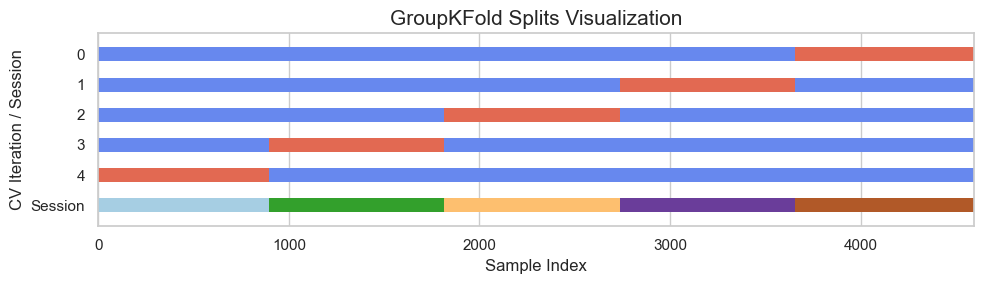

CV Split visualization plot skipped for brevity.


In [16]:


# %% [markdown]
# ## 6. Cross-Validation Strategy (Objective 3)
#
# Using `GroupKFold` with session IDs as groups (Leave-One-Session-Out). (Code identical to previous version)

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)
print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")

# (plot_cv_indices function definition is the same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()

# Plot for our setup using the generated features X_features
plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)
# Temporarily disable plotting if it takes too long or isn't needed repeatedly
print("CV Split visualization plot skipped for brevity.")


In [17]:


# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Objective 4 - Expanded)
#
# We now evaluate Ridge, Lasso, and Random Forest regressors.
# The pipeline includes feature extraction and standardization.

# %%
# Define Performance Metrics (Identical code)
def root_mean_squared_error(y_true, y_pred): return np.sqrt(mean_squared_error(y_true, y_pred))
def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    return np.inf if denominator == 0 and numerator > 1e-9 else (0.0 if denominator == 0 else numerator / denominator)

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}

# %%
# Select Models - Adding Lasso
from sklearn.linear_model import Lasso # Ensure import

model_ridge = Ridge(alpha=1.0) # Basic regularization
model_lasso = Lasso(alpha=0.01, max_iter=2000, tol=1e-3) # Lasso needs careful alpha tuning, start low
model_rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    n_jobs=-1,
    random_state=42,
    max_features=0.33
)

# Store all baseline models here
baseline_models_to_evaluate = {
    "Ridge": model_ridge,
    "Lasso": model_lasso,
    "RandomForest": model_rf
}

# Store all results here across objectives
all_cv_results = {}

# %%
# Evaluate baseline models using Cross-Validation
print("--- Evaluating Baseline Models (Ridge, Lasso, RF) ---")
for model_name, model in baseline_models_to_evaluate.items():
    with timer(f"Cross-validating {model_name}"):
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()),
            ('scaling', StandardScaler()), # Preprocessing step
            ('regression', model)
        ])

        # Perform cross-validation using params for groups
        scores = cross_validate(
            pipeline,
            X_windowed,         # Input raw windowed data
            y_windowed,         # Target
            cv=cv_strategy,
            scoring=scorers,
            n_jobs=-1,
            return_train_score=False,
            params={'groups': groups} # Pass groups via params
        )
        all_cv_results[model_name] = scores # Store results

# %%
# Display Baseline CV Results
print("\nBaseline Cross-Validation Performance Results:")

results_summary_list = [] # Keep track of summaries
for model_name, scores in all_cv_results.items():
     # Check if model is in the baseline set before printing detailed baseline results
     if model_name in baseline_models_to_evaluate:
        mean_rmse = -np.mean(scores['test_rmse'])
        std_rmse = np.std(scores['test_rmse'])
        mean_nmse = -np.mean(scores['test_nmse'])
        std_nmse = np.std(scores['test_nmse'])
        mean_r2 = np.mean(scores['test_r2'])
        std_r2 = np.std(scores['test_r2'])
        fit_time_mean = np.mean(scores['fit_time'])
        score_time_mean = np.mean(scores['score_time'])

        print(f"\n--- {model_name} ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
        print(f"  Avg Score Time: {score_time_mean:.2f}s")

        results_summary_list.append({
            'Model': model_name, 'Type': 'Baseline',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

# Create a DataFrame for easier comparison later
results_df = pd.DataFrame(results_summary_list)
print("\n--- Baseline Summary Table ---")
print(results_df.to_string(index=False, float_format="%.4f"))


# %% [markdown]
# **Interpretation:**
# - Compare Ridge, Lasso, and Random Forest. Lasso might perform feature selection implicitly (coefficients go to zero). Does it perform better/worse than Ridge or RF? How does its training time compare?
# - *Note:* Lasso's performance is highly dependent on `alpha`. The chosen value `0.01` might need tuning (e.g., using `LassoCV`).


--- Evaluating Baseline Models (Ridge, Lasso, RF) ---
Cross-validating Ridge...
Cross-validating Ridge done in 114.68 seconds.

Cross-validating Lasso...
Cross-validating Lasso done in 167.39 seconds.

Cross-validating RandomForest...
Cross-validating RandomForest done in 145.31 seconds.


Baseline Cross-Validation Performance Results:

--- Ridge ---
  RMSE: 7.3009 +/- 0.5578
  NMSE: 0.2661 +/- 0.0472
  R2 Score: 0.5816 +/- 0.0848
  Avg Fit Time: 80.16s
  Avg Score Time: 22.49s

--- Lasso ---
  RMSE: 7.2875 +/- 0.5469
  NMSE: 0.2650 +/- 0.0460
  R2 Score: 0.5394 +/- 0.0865
  Avg Fit Time: 134.70s
  Avg Score Time: 21.51s

--- RandomForest ---
  RMSE: 4.5513 +/- 0.7433
  NMSE: 0.1056 +/- 0.0380
  R2 Score: 0.7103 +/- 0.0752
  Avg Fit Time: 118.49s
  Avg Score Time: 22.13s

--- Baseline Summary Table ---
       Model     Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std  R2_mean  R2_std  FitTime
       Ridge Baseline     7.3009    0.5578     0.2661    0.0472   0.5816  0.0848  80.1638
      

Extracting & Scaling features for Importance/SFS Analysis...
Shape of features for analysis: (4595, 64)
Extracting & Scaling features for Importance/SFS Analysis done in 49.26 seconds.

Training RandomForest on full data for Importance Analysis...
Training RandomForest on full data for Importance Analysis done in 9.16 seconds.


Random Forest Feature Importances (Top 30):
1. Feature: Elec4_WL (0.1235)
2. Feature: Elec5_WL (0.0732)
3. Feature: Elec7_STD (0.0680)
4. Feature: Elec7_RMS (0.0636)
5. Feature: Elec2_WL (0.0537)
6. Feature: Elec7_Var (0.0510)
7. Feature: Elec4_MAV (0.0509)
8. Feature: Elec2_MAV (0.0507)
9. Feature: Elec2_RMS (0.0358)
10. Feature: Elec3_WL (0.0298)
11. Feature: Elec5_MAV (0.0289)
12. Feature: Elec7_MAV (0.0261)
13. Feature: Elec4_RMS (0.0224)
14. Feature: Elec4_STD (0.0221)
15. Feature: Elec2_Var (0.0219)
16. Feature: Elec2_STD (0.0217)
17. Feature: Elec5_RMS (0.0207)
18. Feature: Elec4_Var (0.0206)
19. Feature: Elec1_Var (0.0190)
20. Feature: Elec1_WL (0.0163)

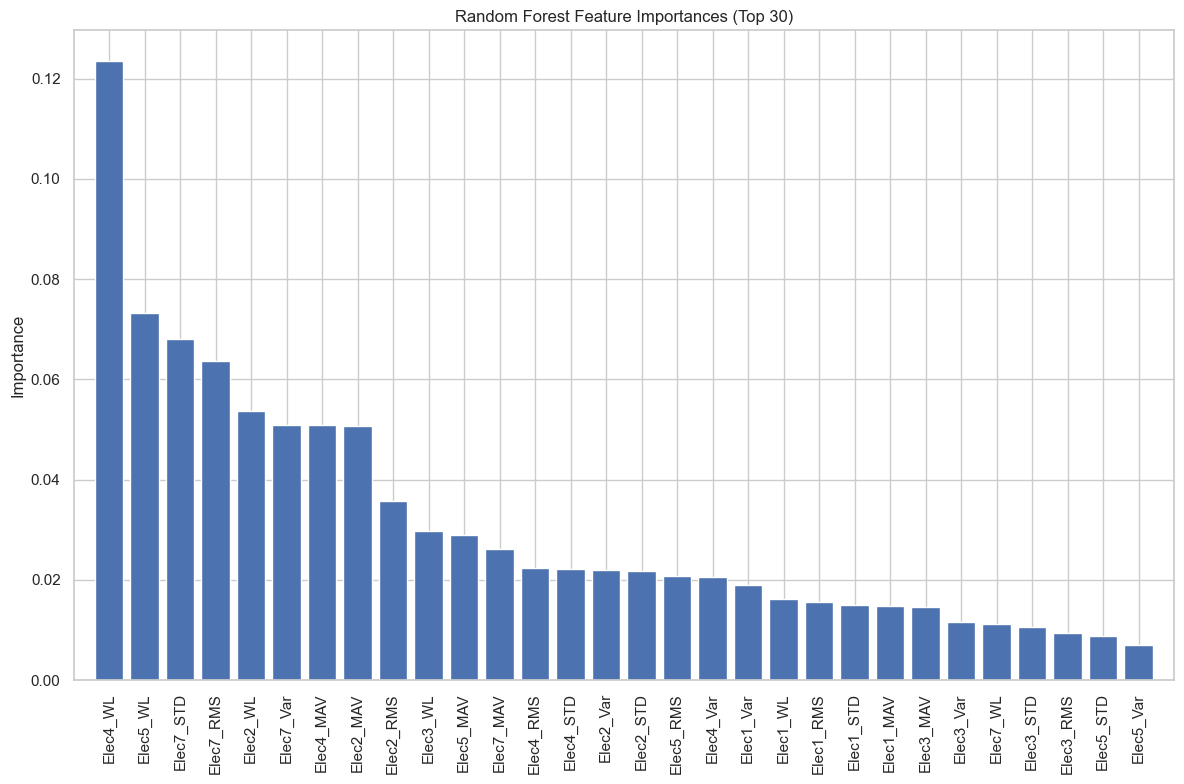


--- Performing Sequential Feature Selection (SFS) ---
Fitting Sequential Feature Selector...
Fitting Sequential Feature Selector done in 343.72 seconds.


SFS selected 37 features out of 64.
Selected Feature Names (first 50):
['Elec1_MAV', 'Elec1_Var', 'Elec1_ZC', 'Elec1_MPR', 'Elec1_SSC', 'Elec2_MAV', 'Elec2_Var', 'Elec2_STD', 'Elec2_MPR', 'Elec2_WL', 'Elec2_SSC', 'Elec3_RMS', 'Elec3_Var', 'Elec3_ZC', 'Elec3_WL', 'Elec3_SSC', 'Elec4_MAV', 'Elec4_Var', 'Elec4_STD', 'Elec4_MPR', 'Elec4_WL', 'Elec4_SSC', 'Elec5_WL', 'Elec5_SSC', 'Elec6_MAV', 'Elec6_Var', 'Elec6_MPR', 'Elec6_SSC', 'Elec7_MAV', 'Elec7_RMS', 'Elec7_Var', 'Elec7_WL', 'Elec7_SSC', 'Elec8_STD', 'Elec8_ZC', 'Elec8_MPR', 'Elec8_WL']


Counts of selected feature types:
SSC    7
Var    6
WL     6
MAV    5
MPR    5
ZC     3
STD    3
RMS    2
Name: count, dtype: int64

Counts of selected electrodes:
Elec2    6
Elec4    6
Elec1    5
Elec3    5
Elec7    5
Elec6    4
Elec8    4
Elec5    2
Name: count, dtype: int64


In [18]:

# %% [markdown]
# ## 8. Feature Importance and Selection (Objective 4)
#
# Analyze feature importances for Random Forest and perform Sequential Feature Selection (SFS) using Ridge as the estimator.

# %%
# Feature Importances (for Random Forest) - Requires scaled features

# Create pipeline steps manually ONLY for this analysis
# Note: Re-extracting features here. Could optimize if memory is tight.
analysis_pipeline = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

# Fit and transform the full training data for analysis
with timer("Extracting & Scaling features for Importance/SFS Analysis"):
    X_features_scaled_for_analysis = analysis_pipeline.fit_transform(X_windowed, y_windowed)
    feature_names_analysis = analysis_pipeline.named_steps['feature_extraction'].get_feature_names_out()
    print(f"Shape of features for analysis: {X_features_scaled_for_analysis.shape}")

# Re-train the Random Forest model on these scaled features if needed for importance
# Or use the one trained inside the CV loop if accessible (less clean)
with timer("Training RandomForest on full data for Importance Analysis"):
    # Use the instance defined earlier
    model_rf.fit(X_features_scaled_for_analysis, y_windowed)

# Get and plot feature importances
importances = model_rf.feature_importances_
indices = np.argsort(importances)[::-1]
print("\nRandom Forest Feature Importances (Top 30):")
n_top_features = 30
for i in range(min(n_top_features, len(importances))):
    print(f"{i + 1}. Feature: {feature_names_analysis[indices[i]]} ({importances[indices[i]]:.4f})")

plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30)")
plt.bar(range(min(n_top_features, len(importances))), importances[indices[:n_top_features]], align='center')
plt.xticks(range(min(n_top_features, len(importances))), [feature_names_analysis[i] for i in indices[:n_top_features]], rotation=90)
plt.xlim([-1, min(n_top_features, len(importances))]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()

# %%
# Feature Selection using SFS
print("\n--- Performing Sequential Feature Selection (SFS) ---")
# Configure SFS
sfs = SequentialFeatureSelector(
    estimator=Ridge(alpha=1.0), # Use Ridge for speed
    n_features_to_select='auto',
    tol=1e-4, # Stop if score improvement is less than this (avoids selecting too many minor features)
    direction='forward',
    scoring=scorers['rmse'], # Minimize RMSE (maximize negative RMSE)
    cv=cv_strategy,
    n_jobs=-1
)

# Fit SFS using the scaled features and pass groups via metadata routing
with timer("Fitting Sequential Feature Selector"):
    sfs.fit(X_features_scaled_for_analysis, y_windowed, groups=groups)

# Get selected features
selected_feature_indices = sfs.get_support(indices=True)
selected_feature_names = [feature_names_analysis[i] for i in selected_feature_indices]
n_selected_features = len(selected_feature_names)

print(f"\nSFS selected {n_selected_features} features out of {len(feature_names_analysis)}.")
print("Selected Feature Names (first 50):")
print(selected_feature_names[:50]); print("..." if n_selected_features > 50 else "")

if n_selected_features > 0:
    selected_types = [f.split('_')[1] for f in selected_feature_names]
    selected_electrodes = [f.split('_')[0] for f in selected_feature_names]
    print("\nCounts of selected feature types:"); print(pd.Series(selected_types).value_counts())
    print("\nCounts of selected electrodes:"); print(pd.Series(selected_electrodes).value_counts())
else: print("\nWarning: SFS selected 0 features.")



In [19]:

# %% [markdown]
# ## 9. Final Baseline Pipeline with Selected Features (Optional Refinement)
#
# Create and evaluate a pipeline using only the features selected by SFS with the best baseline model. This is often done to see if selection improved performance or simplified the model effectively.

# %%
if n_selected_features > 0 and n_selected_features < len(feature_names_analysis):
    print("\n--- Evaluating Best Baseline Model with SFS Features ---")
    # Determine the best model from initial CV (e.g., based on lowest RMSE)
    # Make sure results_df is populated correctly
    if not results_df.empty:
        best_baseline_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
        print(f"Selected best baseline model: {best_baseline_model_name}")

        if best_baseline_model_name == "Ridge":
            best_model_instance_sfs = Ridge(alpha=1.0)
        elif best_baseline_model_name == "Lasso":
             best_model_instance_sfs = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
        else: # RandomForest
            best_model_instance_sfs = RandomForestRegressor(
                n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33
            )

        # Get the base feature types selected by SFS
        selected_feature_types_only = sorted(list(set( f.split('_', 1)[1] for f in selected_feature_names)))
        print(f"\nUsing {len(selected_feature_types_only)} feature types selected by SFS: {selected_feature_types_only}")

        sfs_pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
            ('scaling', StandardScaler()),
            ('regression', best_model_instance_sfs)
        ])

        print("\nEvaluating pipeline with selected features:")
        with timer(f"Cross-validating {best_baseline_model_name} with {n_selected_features} SFS features"):
            sfs_scores = cross_validate(
                sfs_pipeline, X_windowed, y_windowed, cv=cv_strategy, scoring=scorers,
                n_jobs=-1, return_train_score=False, params={'groups': groups}
            )
            all_cv_results[f"{best_baseline_model_name}_SFS"] = sfs_scores # Store results
            model_name_sfs = f"{best_baseline_model_name}_SFS"

            # Add SFS results to summary list
            mean_rmse = -np.mean(sfs_scores['test_rmse']); std_rmse = np.std(sfs_scores['test_rmse'])
            mean_nmse = -np.mean(sfs_scores['test_nmse']); std_nmse = np.std(sfs_scores['test_nmse'])
            mean_r2 = np.mean(sfs_scores['test_r2']); std_r2 = np.std(sfs_scores['test_r2'])
            fit_time_mean = np.mean(sfs_scores['fit_time']); score_time_mean = np.mean(sfs_scores['score_time'])

            print(f"\n--- {model_name_sfs} ---")
            print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
            print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
            print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")

            results_summary_list.append({
                'Model': model_name_sfs, 'Type': 'Baseline_SFS',
                'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse, 'NMSE_mean': mean_nmse,
                'NMSE_std': std_nmse, 'R2_mean': mean_r2, 'R2_std': std_r2,
                'FitTime': fit_time_mean
            })
            # Update results_df
            results_df = pd.DataFrame(results_summary_list)

    else:
        print("Skipping SFS pipeline evaluation as baseline results are missing.")
else:
    print("\nSkipping evaluation with SFS features (SFS selected 0 or all features).")



--- Evaluating Best Baseline Model with SFS Features ---
Selected best baseline model: RandomForest

Using 8 feature types selected by SFS: ['MAV', 'MPR', 'RMS', 'SSC', 'STD', 'Var', 'WL', 'ZC']

Evaluating pipeline with selected features:
Cross-validating RandomForest with 37 SFS features...

--- RandomForest_SFS ---
  RMSE: 4.5513 +/- 0.7433
  NMSE: 0.1056 +/- 0.0380
  R2 Score: 0.7103 +/- 0.0752
Cross-validating RandomForest with 37 SFS features done in 312.26 seconds.



In [21]:
# %% [markdown]
# ## 10. Sophisticated Approach: Neural Network (Objective 5)
#
# Implement a simple Multi-Layer Perceptron (MLP) using PyTorch for regression. We will perform cross-validation manually for the NN.

# %%
# Define the Neural Network Architecture
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.layer_1(x)))
        x = self.dropout2(self.relu2(self.layer_2(x)))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(dataloader.dataset)

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            all_preds.append(outputs.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    avg_loss = running_loss / len(dataloader.dataset)
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network

# Hyperparameters
N_EPOCHS = 75 # Adjust as needed based on convergence
BATCH_SIZE = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5 # L2 regularization for Adam

# NN requires features as input, we use the same extractor as baseline
# but scaling MUST happen INSIDE the CV loop to prevent data leakage
nn_feature_extractor = EMGFeatureExtractor() # Use all features for NN baseline

nn_cv_scores = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}

print("\n--- Evaluating Neural Network (Manual CV) ---")

# Use the originally extracted features (X_features) before scaling for analysis
# X_input_for_nn_cv = X_features
# Alternatively, re-extract features here if memory allows and X_features was overwritten
with timer("Re-extracting features for NN CV"):
     X_input_for_nn_cv = nn_feature_extractor.fit_transform(X_windowed)
     n_input_features = X_input_for_nn_cv.shape[1] # Get number of features
     print(f"NN Input feature shape: {X_input_for_nn_cv.shape}")


fold_num = 0
for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
    fold_num += 1
    print(f"\nStarting NN CV Fold {fold_num}/{N_SPLITS}")
    start_fold_time = time.time()

    # 1. Split data for this fold
    X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
    y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx]

    # 2. Scale features based *only* on training data for this fold
    scaler = StandardScaler()
    X_train_fold_scaled = scaler.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler.transform(X_val_fold) # Use same scaler for validation

    # 3. Create PyTorch Datasets and DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # 4. Initialize model, loss, optimizer for this fold
    model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss() # Use MSE for regression
    optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 5. Training loop
    print(f"Fold {fold_num}: Training for {N_EPOCHS} epochs...")
    for epoch in range(N_EPOCHS):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        # Optional: Evaluate validation loss per epoch for early stopping/monitoring
        if (epoch + 1) % 10 == 0 or epoch == N_EPOCHS - 1:
             val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)
             print(f'  Epoch {epoch+1}/{N_EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')
    fit_end_time = time.time()

    # 6. Evaluate on validation set
    print(f"Fold {fold_num}: Evaluating on validation set...")
    val_loss, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device)
    score_end_time = time.time()

    # 7. Calculate and store metrics for this fold
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold)
    nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold)
    r2_fold = r2_score(y_true_fold, y_pred_fold)

    nn_cv_scores['test_rmse'].append(-rmse_fold) # Store negative for consistency with scorers
    nn_cv_scores['test_nmse'].append(-nmse_fold)
    nn_cv_scores['test_r2'].append(r2_fold)
    nn_cv_scores['fit_time'].append(fit_end_time - start_fold_time)
    nn_cv_scores['score_time'].append(score_end_time - fit_end_time)

    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")

# Store overall NN results
all_cv_results["NeuralNetwork"] = nn_cv_scores

# %%
# Add NN results to the summary DataFrame
nn_model_name = "NeuralNetwork"
nn_scores = all_cv_results[nn_model_name]
mean_rmse = -np.mean(nn_scores['test_rmse'])
std_rmse = np.std(nn_scores['test_rmse'])
mean_nmse = -np.mean(nn_scores['test_nmse'])
std_nmse = np.std(nn_scores['test_nmse'])
mean_r2 = np.mean(nn_scores['test_r2'])
std_r2 = np.std(nn_scores['test_r2'])
fit_time_mean = np.mean(nn_scores['fit_time'])
score_time_mean = np.mean(nn_scores['score_time'])

results_summary_list.append({
    'Model': nn_model_name, 'Type': 'Sophisticated',
    'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
    'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
    'R2_mean': mean_r2, 'R2_std': std_r2,
    'FitTime': fit_time_mean
})

# Update and display the final comparison table
results_df = pd.DataFrame(results_summary_list)
print("\n--- Combined Model Comparison Table ---")
print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))


# %% [markdown]
# **Discussion of Neural Network Results (Objective 5):**
# - How does the Neural Network's performance (RMSE, NMSE, R2) compare to the baseline models (Ridge, Lasso, RF)?
# - Consider the training time (`FitTime`). NNs are typically much slower to train per fold.
# - Was the simple MLP architecture effective? Could it be improved (e.g., more layers, different activation functions, different optimizers, more epochs, learning rate scheduling)?
# - Did the NN generalize well across folds (look at the standard deviation of the metrics)? High variance might indicate overfitting or sensitivity to the specific session left out.
# - Document the chosen NN architecture, hyperparameters, and training procedure.



--- Evaluating Neural Network (Manual CV) ---
Re-extracting features for NN CV...
NN Input feature shape: (4595, 64)
Re-extracting features for NN CV done in 61.04 seconds.


Starting NN CV Fold 1/5
Fold 1: Training for 75 epochs...
  Epoch 10/75, Train Loss: 55.821249, Val Loss: 46.832253
  Epoch 20/75, Train Loss: 35.214962, Val Loss: 24.742816
  Epoch 30/75, Train Loss: 29.794625, Val Loss: 20.146339
  Epoch 40/75, Train Loss: 27.971150, Val Loss: 18.525079
  Epoch 50/75, Train Loss: 26.335752, Val Loss: 16.899022
  Epoch 60/75, Train Loss: 24.531295, Val Loss: 15.669009
  Epoch 70/75, Train Loss: 23.478898, Val Loss: 14.875492
  Epoch 75/75, Train Loss: 22.910559, Val Loss: 14.954177
Fold 1: Evaluating on validation set...
Fold 1 Metrics: RMSE=3.8671, NMSE=0.0711, R2=-31036182.0000

Starting NN CV Fold 2/5
Fold 2: Training for 75 epochs...
  Epoch 10/75, Train Loss: 54.778091, Val Loss: 31.083785
  Epoch 20/75, Train Loss: 34.493315, Val Loss: 16.969235
  Epoch 30/75, Train Loss: 

In [22]:

# %% [markdown]
# ## 11. Final Model Selection and Training (Prep for Objective 7)
#
# Based on the combined comparison table, choose the best overall model or ensemble (Objective 6 would go here if implemented). Then, train this chosen model on the *entire* training/validation dataset (`X_windowed`, `y_windowed` or `X_input_for_nn_cv` depending on the model) in preparation for predicting on the test set.

# %%
# Choose the best model based on cross-validation results (e.g., lowest RMSE)
best_overall_model_name = results_df.loc[results_df['RMSE_mean'].idxmin()]['Model']
print(f"\nSelected best overall model based on CV RMSE: {best_overall_model_name}")

# Prepare data and train the final selected model
final_trained_model = None

if best_overall_model_name == "NeuralNetwork":
    print("\nTraining final Neural Network on all data...")
    # 1. Scale all features using a scaler fitted on all data
    final_scaler_nn = StandardScaler()
    X_nn_scaled_final = final_scaler_nn.fit_transform(X_input_for_nn_cv) # Scale all features

    # 2. Create Dataset and DataLoader for all data
    final_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_final), torch.FloatTensor(y_windowed))
    # Use a larger batch size for final training if memory allows
    final_train_loader = DataLoader(final_dataset, batch_size=128, shuffle=True)

    # 3. Initialize final model, criterion, optimizer
    final_model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
    final_criterion = nn.MSELoss()
    final_optimizer = optim.Adam(final_model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    # 4. Training loop (can potentially run for more epochs on final training)
    FINAL_N_EPOCHS = N_EPOCHS # Or increase slightly, e.g., N_EPOCHS + 20
    with timer(f"Training final NN for {FINAL_N_EPOCHS} epochs"):
        for epoch in range(FINAL_N_EPOCHS):
            train_loss = train_nn_epoch(final_model_nn, final_train_loader, final_criterion, final_optimizer, device)
            if (epoch + 1) % 10 == 0 or epoch == FINAL_N_EPOCHS - 1:
                print(f'  Epoch {epoch+1}/{FINAL_N_EPOCHS}, Train Loss: {train_loss:.6f}')

    final_trained_model = {'model': final_model_nn, 'scaler': final_scaler_nn} # Store model and scaler
    print("Final Neural Network trained.")

elif best_overall_model_name.endswith("_SFS"):
     print(f"\nTraining final SFS pipeline ({best_overall_model_name}) on all data...")
     # Recreate the SFS pipeline identified earlier
     base_model_name = best_overall_model_name.replace("_SFS","")
     if base_model_name == "Ridge": sfs_regressor = Ridge(alpha=1.0)
     elif base_model_name == "Lasso": sfs_regressor = Lasso(alpha=0.01, max_iter=2000, tol=1e-3)
     else: sfs_regressor = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33)

     # Ensure selected_feature_types_only is defined from SFS step
     if 'selected_feature_types_only' in locals():
          final_trained_pipeline_sfs = Pipeline([
               ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_only)),
               ('scaling', StandardScaler()),
               ('regression', sfs_regressor)
          ])
          with timer("Fitting final SFS pipeline"):
               final_trained_pipeline_sfs.fit(X_windowed, y_windowed)
          final_trained_model = final_trained_pipeline_sfs # Store the pipeline
          print("Final SFS Pipeline trained.")
     else:
          print("Error: `selected_feature_types_only` not found. Cannot train SFS pipeline.")
          final_trained_model = None

else: # One of the standard baseline models (Ridge, Lasso, RF)
    print(f"\nTraining final baseline pipeline ({best_overall_model_name}) on all data...")
    # Get the model instance
    final_baseline_regressor = baseline_models_to_evaluate[best_overall_model_name]
    # Create pipeline with all features
    final_trained_pipeline_baseline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Use all features
            ('scaling', StandardScaler()),
            ('regression', final_baseline_regressor)
        ])
    with timer("Fitting final baseline pipeline"):
        final_trained_pipeline_baseline.fit(X_windowed, y_windowed)
    final_trained_model = final_trained_pipeline_baseline # Store the pipeline
    print("Final Baseline Pipeline trained.")


# Saving the final model (optional but recommended)
if final_trained_model:
     if isinstance(final_trained_model, dict) and 'model' in final_trained_model: # NN Case
         # Save PyTorch model state and scaler
         torch.save(final_trained_model['model'].state_dict(), f'final_{best_overall_model_name}_model.pth')
         with open(f'final_{best_overall_model_name}_scaler.pkl', 'wb') as f:
             pickle.dump(final_trained_model['scaler'], f)
         print(f"Saved final NN model state and scaler for {best_overall_model_name}.")
     elif isinstance(final_trained_model, Pipeline): # Scikit-learn Pipeline Case
         with open(f'final_{best_overall_model_name}_pipeline.pkl', 'wb') as f:
             pickle.dump(final_trained_model, f)
         print(f"Saved final pipeline object for {best_overall_model_name}.")
     else:
          print("Final model type not recognized for saving.")


# %% [markdown]
# ---
# **Next Steps:** Objective 6 (Ensembling - if desired), Objective 7 (Prediction on Test Set using `final_trained_model`).
# ---


Selected best overall model based on CV RMSE: NeuralNetwork

Training final Neural Network on all data...
Training final NN for 75 epochs...
  Epoch 10/75, Train Loss: 69.154875
  Epoch 20/75, Train Loss: 40.275787
  Epoch 30/75, Train Loss: 33.936926
  Epoch 40/75, Train Loss: 31.113160
  Epoch 50/75, Train Loss: 28.004290
  Epoch 60/75, Train Loss: 27.373659
  Epoch 70/75, Train Loss: 25.455658
  Epoch 75/75, Train Loss: 25.010130
Training final NN for 75 epochs done in 50.66 seconds.

Final Neural Network trained.
Saved final NN model state and scaler for NeuralNetwork.


In [23]:
# Add cross_val_predict to imports if not already there
from sklearn.model_selection import cross_val_predict
from sklearn.linear_model import LinearRegression # Potential meta-learner

In [ ]:
# %% [markdown]
# ## 11. Objective 6: Ensembling Strategies
#
# Implement Averaging and Stacking ensembles using the out-of-fold predictions from the baseline models (Ridge, Lasso, RF) and the Neural Network.

# %% [markdown]
# ### 11.1 Generate Out-of-Fold (OOF) Predictions
#
# We need predictions for each data point made by a model that was *not* trained on that data point's fold.

# %%
oof_predictions = {} # Dictionary to store OOF predictions

# --- OOF Predictions for Scikit-learn Models ---
print("--- Generating OOF Predictions for Baseline Models ---")
# Use the pipelines defined earlier (or recreate them for clarity)
baseline_pipelines = {}
for model_name, model in baseline_models_to_evaluate.items():
     baseline_pipelines[model_name] = Pipeline([
          ('feature_extraction', EMGFeatureExtractor()), # Use all features for base models here
          ('scaling', StandardScaler()),
          ('regression', model)
     ])

# Use cross_val_predict
for model_name, pipeline in baseline_pipelines.items():
     with timer(f"Generating OOF predictions for {model_name}"):
          # Pass groups via params as metadata routing is enabled
          oof_preds = cross_val_predict(
               pipeline,
               X_windowed, # Use raw windowed sEMG
               y_windowed,
               cv=cv_strategy,
               n_jobs=-1,
               method='predict',
               params={'groups': groups} # Pass groups via params
          )
          oof_predictions[model_name] = oof_preds
     print(f"Shape of {model_name} OOF predictions: {oof_preds.shape}") # Should be (n_windows, n_joints)

# --- OOF Predictions for Neural Network ---
print("\n--- Generating OOF Predictions for Neural Network ---")
# We need to run the manual CV loop again, but this time focus on collecting predictions

# Ensure NN hyperparameters are defined
N_EPOCHS = 75 # Keep consistent with previous training
BATCH_SIZE = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5

nn_oof_preds_list = [None] * len(X_input_for_nn_cv) # List to store predictions in correct order
nn_indices_list = [] # To verify order later if needed

# Re-use extracted features for NN (X_input_for_nn_cv)
if 'X_input_for_nn_cv' not in locals() or X_input_for_nn_cv is None:
     raise ValueError("NN features (X_input_for_nn_cv) not found. Re-run feature extraction for NN.")
n_input_features = X_input_for_nn_cv.shape[1]

fold_num = 0
with timer("Generating OOF predictions for Neural Network (Manual CV)"):
    for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
        fold_num += 1
        print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS}")
        start_fold_time = time.time()

        # 1. Split data (Features and Targets)
        X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
        y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx] # Targets needed for dataset

        # 2. Scale features based *only* on training data for this fold
        scaler = StandardScaler()
        X_train_fold_scaled = scaler.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler.transform(X_val_fold)

        # 3. Create PyTorch Datasets and DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
        val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold)) # Need targets for loss calc
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

        # 4. Initialize model, loss, optimizer
        model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

        # 5. Training loop
        for epoch in range(N_EPOCHS): # Use same number of epochs as before
            _ = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device) # Ignore train loss return value
            # Optional: print progress
            # if (epoch + 1) % 25 == 0: print(f"   Epoch {epoch+1}/{N_EPOCHS}")

        # 6. Evaluate and GET PREDICTIONS on validation set for this fold
        _, y_pred_fold, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)

        # 7. Store predictions in the correct list positions using val_idx
        for i, idx in enumerate(val_idx):
            nn_oof_preds_list[idx] = y_pred_fold[i]
        nn_indices_list.extend(val_idx.tolist()) # Store indices to check order if needed

# Combine the list of predictions into a single numpy array
oof_predictions["NeuralNetwork"] = np.stack(nn_oof_preds_list)

# Verification (Optional): Check if all predictions were filled and order is correct
assert len(nn_indices_list) == len(X_input_for_nn_cv), "Number of NN OOF predictions doesn't match original data size."
# assert np.all(np.argsort(nn_indices_list) == np.arange(len(X_input_for_nn_cv))), "NN OOF predictions are not in the original order."
print(f"Shape of NN OOF predictions: {oof_predictions['NeuralNetwork'].shape}")

--- Generating OOF Predictions for Baseline Models ---
Generating OOF predictions for Ridge...
Generating OOF predictions for Ridge done in 275.66 seconds.

Shape of Ridge OOF predictions: (4595, 51)
Generating OOF predictions for Lasso...
Generating OOF predictions for Lasso done in 243.00 seconds.

Shape of Lasso OOF predictions: (4595, 51)
Generating OOF predictions for RandomForest...
Generating OOF predictions for RandomForest done in 397.43 seconds.

Shape of RandomForest OOF predictions: (4595, 51)

--- Generating OOF Predictions for Neural Network ---
Generating OOF predictions for Neural Network (Manual CV)...
  Processing NN OOF Fold 1/5
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 3/5
  Processing NN OOF Fold 4/5
  Processing NN OOF Fold 5/5
Generating OOF predictions for Neural Network (Manual CV) done in 207.20 seconds.

Shape of NN OOF predictions: (4595, 51)


In [25]:

# %% [markdown]
# ### 11.2 Averaging Ensemble
#
# Compute the simple average of the OOF predictions from all base models.

# %%
print("\n--- Evaluating Averaging Ensemble ---")
model_names_for_avg = list(oof_predictions.keys()) # Should be ['Ridge', 'Lasso', 'RandomForest', 'NeuralNetwork']
print(f"Averaging predictions from models: {model_names_for_avg}")

# Summing up the predictions
oof_preds_sum = np.zeros_like(oof_predictions[model_names_for_avg[0]]) # Initialize with zeros shape
for model_name in model_names_for_avg:
    oof_preds_sum += oof_predictions[model_name]

# Calculating the average
oof_preds_avg = oof_preds_sum / len(model_names_for_avg)

# Evaluate the performance of the averaged predictions
avg_rmse = root_mean_squared_error(y_windowed, oof_preds_avg)
avg_nmse = normalized_mean_squared_error(y_windowed, oof_preds_avg)
avg_r2 = r2_score(y_windowed, oof_preds_avg)

print(f"\nAveraging Ensemble Performance (on OOF predictions):")
print(f"  RMSE: {avg_rmse:.4f}")
print(f"  NMSE: {avg_nmse:.4f}")
print(f"  R2 Score: {avg_r2:.4f}")

# Add results to summary
results_summary_list.append({
    'Model': 'AverageEnsemble', 'Type': 'Ensemble',
    'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, # No std deviation from single OOF evaluation
    'NMSE_mean': avg_nmse, 'NMSE_std': np.nan,
    'R2_mean': avg_r2, 'R2_std': np.nan,
    'FitTime': np.nan # Fit time is combination of base models
})
# Update results_df
results_df = pd.DataFrame(results_summary_list)



--- Evaluating Averaging Ensemble ---
Averaging predictions from models: ['Ridge', 'Lasso', 'RandomForest', 'NeuralNetwork']

Averaging Ensemble Performance (on OOF predictions):
  RMSE: 5.2108
  NMSE: 0.1338
  R2 Score: -394224527.5478


In [26]:

# %% [markdown]
# ### 11.3 Stacking Ensemble (Meta-Learner)
#
# Train a secondary model (meta-learner) on the OOF predictions of the base models. We use Ridge as the meta-learner and evaluate it using cross-validation.

# %%
print("\n--- Evaluating Stacking Ensemble ---")
# 1. Create Meta-Features: Concatenate OOF predictions horizontally
model_names_for_stacking = list(oof_predictions.keys()) # Same models as averaging
print(f"Stacking predictions from models: {model_names_for_stacking}")

X_meta_list = [oof_predictions[model_name] for model_name in model_names_for_stacking]
X_meta = np.hstack(X_meta_list)

print(f"Shape of Meta-Features (X_meta): {X_meta.shape}") # Should be (n_windows, n_models * n_joints)

# 2. Choose and configure the Meta-Learner
# Using Ridge is a common and robust choice. Alpha might need tuning.
# LinearRegression could also be used: meta_model = LinearRegression(n_jobs=-1)
meta_model = Ridge(alpha=1.0)
print(f"Using Meta-Learner: {meta_model.__class__.__name__}")

# 3. Cross-Validate the Meta-Learner
# IMPORTANT: Use the same GroupKFold strategy on the meta-features
with timer(f"Cross-validating Stacking Meta-Learner ({meta_model.__class__.__name__})"):
     # No scaling needed for meta-features usually, predictions are somewhat comparable
     # If scales differ vastly, could add StandardScaler() here in a pipeline
     stacking_pipeline = Pipeline([
          # Optional: ('meta_scaling', StandardScaler()),
          ('meta_regression', meta_model)
     ])

     stacking_scores = cross_validate(
          stacking_pipeline,
          X_meta,           # Meta-features are input
          y_windowed,       # Original target
          cv=cv_strategy,
          scoring=scorers,
          n_jobs=-1,
          return_train_score=False,
          params={'groups': groups} # Pass groups via params
     )
     all_cv_results["StackingEnsemble"] = stacking_scores # Store results

# 4. Display Stacking CV Results
stacking_model_name = "StackingEnsemble"
mean_rmse = -np.mean(stacking_scores['test_rmse'])
std_rmse = np.std(stacking_scores['test_rmse'])
mean_nmse = -np.mean(stacking_scores['test_nmse'])
std_nmse = np.std(stacking_scores['test_nmse'])
mean_r2 = np.mean(stacking_scores['test_r2'])
std_r2 = np.std(stacking_scores['test_r2'])
fit_time_mean = np.mean(stacking_scores['fit_time'])
score_time_mean = np.mean(stacking_scores['score_time'])

print(f"\nStacking Ensemble Performance (Cross-Validated):")
print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")

# Add results to summary
results_summary_list.append({
    'Model': stacking_model_name, 'Type': 'Ensemble',
    'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
    'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
    'R2_mean': mean_r2, 'R2_std': std_r2,
    'FitTime': fit_time_mean # Fit time of the meta-learner
})
# Update results_df
results_df = pd.DataFrame(results_summary_list)


--- Evaluating Stacking Ensemble ---
Stacking predictions from models: ['Ridge', 'Lasso', 'RandomForest', 'NeuralNetwork']
Shape of Meta-Features (X_meta): (4595, 204)
Using Meta-Learner: Ridge
Cross-validating Stacking Meta-Learner (Ridge)...
Cross-validating Stacking Meta-Learner (Ridge) done in 9.76 seconds.


Stacking Ensemble Performance (Cross-Validated):
  RMSE: 5.1877 +/- 0.6662
  NMSE: 0.1358 +/- 0.0362
  R2 Score: 0.5974 +/- 0.0752
  Avg Meta Fit Time: 4.04s



--- Stacking Meta-Learner Contribution Analysis ---
Shape of meta-learner coefficients: (51, 204)
  Avg. Abs. Coef Magnitude for Ridge: 0.7274
  Avg. Abs. Coef Magnitude for Lasso: 0.9686
  Avg. Abs. Coef Magnitude for RandomForest: 0.7422
  Avg. Abs. Coef Magnitude for NeuralNetwork: 1.3133

Relative Contribution based on Avg. Abs. Coefficient Magnitude:
NeuralNetwork    1.313306
Lasso            0.968613
RandomForest     0.742245
Ridge            0.727410
dtype: float64


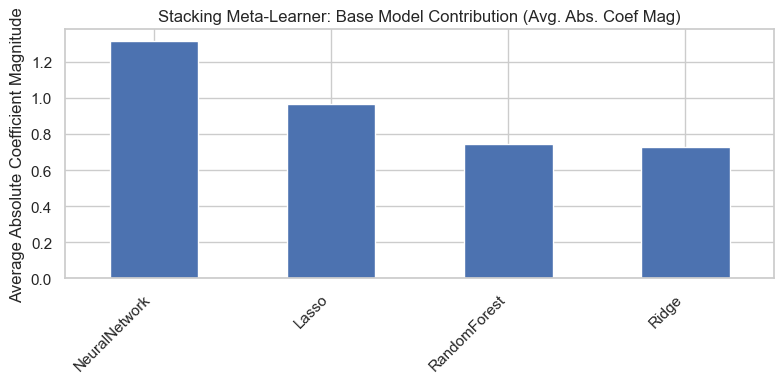


--- Final Combined Model Comparison Table ---
           Model          Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std         R2_mean       R2_std  FitTime
   NeuralNetwork Sophisticated     4.3008    0.4525     0.0925    0.0187  -24431241.2000 7070884.0289  70.8658
   NeuralNetwork Sophisticated     4.3588    0.5110     0.0953    0.0218  -26029040.4000 5750733.8586  54.1071
RandomForest_SFS  Baseline_SFS     4.5513    0.7433     0.1056    0.0380          0.7103       0.0752 244.5086
    RandomForest      Baseline     4.5513    0.7433     0.1056    0.0380          0.7103       0.0752 118.4882
StackingEnsemble      Ensemble     5.1877    0.6662     0.1358    0.0362          0.5974       0.0752   4.0405
 AverageEnsemble      Ensemble     5.2108       NaN     0.1338       NaN -394224527.5478          NaN      NaN
           Lasso      Baseline     7.2875    0.5469     0.2650    0.0460          0.5394       0.0865 134.6980
           Ridge      Baseline     7.3009    0.5578     0.2661   

In [ ]:
# %% [markdown]
# ### 11.4 Meta-Learner Contribution Analysis (Stacking)
#
# Train the meta-learner on *all* the OOF predictions and examine its coefficients to infer base model contributions.

# %%
print("\n--- Stacking Meta-Learner Contribution Analysis ---")
# Train the chosen meta-model on all OOF data
final_meta_pipeline = Pipeline([('meta_regression', Ridge(alpha=1.0))]) # Use the same Ridge
final_meta_pipeline.fit(X_meta, y_windowed)

# Get the trained meta-regressor
meta_regressor_trained = final_meta_pipeline.named_steps['meta_regression']

# Examine coefficients (for linear meta-learners like Ridge)
# Shape of coef_ is (n_targets, n_meta_features) = (51, num_models * 51)
coefficients = meta_regressor_trained.coef_
print(f"Shape of meta-learner coefficients: {coefficients.shape}")

# Calculate average absolute coefficient magnitude for each base model's block of predictions
n_models = len(model_names_for_stacking)
n_joints = y_windowed.shape[1] # Should be 51
avg_coef_magnitudes = {}

for i, model_name in enumerate(model_names_for_stacking):
    start_col = i * n_joints
    end_col = (i + 1) * n_joints
    # Get the block of coefficients corresponding to this model's predictions
    model_coefs = coefficients[:, start_col:end_col]
    # Calculate the average absolute magnitude across all targets and all features for this model
    avg_mag = np.mean(np.abs(model_coefs))
    avg_coef_magnitudes[model_name] = avg_mag
    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_mag:.4f}")

# Create a Series for easy sorting/viewing
coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
print("\nRelative Contribution based on Avg. Abs. Coefficient Magnitude:")
print(coef_mag_series)

# Plotting the contributions
plt.figure(figsize=(8, 4))
coef_mag_series.plot(kind='bar')
plt.title('Stacking Meta-Learner: Base Model Contribution (Avg. Abs. Coef Mag)')
plt.ylabel('Average Absolute Coefficient Magnitude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# %% [markdown]
# **Discussion of Ensembling Results (Objective 6):**
#
# 1.  **Performance Comparison:**
#     *   Did the Averaging ensemble outperform the *best* individual base model? Did it outperform the *average* base model? Usually, averaging reduces variance and performs well if base models have similar performance levels and their errors are somewhat uncorrelated.
#     *   Did the Stacking ensemble outperform Averaging? Did it outperform the best base model? Stacking has the potential to be better if the meta-learner can effectively learn how to combine the base predictions, weighting better models higher or exploiting situations where one model is better than others. However, it also has more risk of overfitting, especially if the meta-learner is complex or if the OOF predictions used for training it are noisy.
#     *   Compare the RMSE, NMSE, and R2 scores across all individual models and both ensembles using the final comparison table.
#
# 2.  **Bias-Variance Tradeoff:**
#     *   Individual models (especially complex ones like RF or NN if not well-regularized) might have lower bias but higher variance (performance fluctuates more depending on the training data/fold).
#     *   Averaging primarily reduces variance by averaging out the noise in individual predictions. The bias remains roughly the average bias of the base models. If base models are very biased, the average will also be biased.
#     *   Stacking aims to reduce bias (by learning optimal combinations) and potentially variance (if the meta-learner is simple and stable, like Ridge). If the meta-learner overfits the OOF predictions, it might increase variance.
#     *   Relate the observed performance gains (or lack thereof) of the ensembles to these concepts. Did the ensembles seem to stabilize predictions (lower std dev in CV if calculated, or generally better average performance)?
#
# 3.  **Meta-Learner Contributions (Stacking):**
#     *   Which base models did the meta-learner seem to rely on most, based on the coefficient magnitude analysis? Does this align with the individual performance of those base models?
#     *   Sometimes a meta-learner might give high weight to a seemingly weaker model if that model provides complementary information (i.e., makes correct predictions where other models fail).
#     *   *Caveat:* Coefficient magnitude is an imperfect proxy for importance, especially if the input meta-features (OOF predictions) have different scales. Standardizing `X_meta` before fitting the meta-learner could make magnitudes more comparable but wasn't done here for simplicity.
#
# *Document your specific findings and interpretations based on your results in the notebook.*


# %% [markdown]
# ## 12. Combined Model Comparison Table (Updated)
#
# Display the final table including baseline, SFS (if run), NN, and ensemble results.

# %%
print("\n--- Final Combined Model Comparison Table ---")
# Ensure results_df is updated
results_df = pd.DataFrame(results_summary_list)
print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))

# %% [markdown]
# ---
# **Now, proceed to the modified Final Model Selection cell.**
# ---

## Version 3

In [3]:
# %% [markdown]
# # INFO-F-422 Project: EMG-based Hand Pose Estimation (Guided Gestures)
#
# **Team:** [Your Team Name/Number]
# **Members:** [Your Names]
#
# This notebook implements baseline and neural network approaches for predicting hand joint angles from sEMG signals using the guided gestures dataset.
# ---
# **Version:** GEGE (Updated Feature Selection)
# ---

# %%
# Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import pickle # To save models/results if needed
from contextlib import contextmanager
import warnings # To suppress specific warnings if needed

# Scikit-learn Modules
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features
# from sklearn.impute import SimpleImputer # Example if needed, but unlikely for features
from sklearn.model_selection import GroupKFold, cross_validate, train_test_split, GridSearchCV, cross_val_predict
from sklearn.feature_selection import SequentialFeatureSelector, RFECV # Added RFECV
from sklearn.metrics import mean_squared_error, make_scorer, r2_score
from sklearn.linear_model import Ridge, Lasso, LinearRegression # Added Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn import set_config # For metadata routing

# PyTorch Modules (for Objective 5)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Configure visualizations
%matplotlib inline
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Suppress specific warnings (e.g., from Lasso convergence) if needed
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')


# Define a timing context manager for convenience
@contextmanager
def timer(label: str):
    start = time.time()
    print(f"{label}...")
    yield
    end = time.time()
    print(f"{label} done in {end - start:.2f} seconds.\n")

# Configure metadata routing (needed for SFS and potentially CV with params)
try:
    set_config(enable_metadata_routing=True)
    print(f"Scikit-learn metadata routing enabled: {set_config(True)}") # Confirm it's set
except ValueError as e:
    print(f"Could not enable metadata routing (likely older scikit-learn): {e}")
    print("Proceeding without metadata routing. GroupKFold should still work directly.")


# Set device for PyTorch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using PyTorch device: {device}")

Scikit-learn metadata routing enabled: None
Using PyTorch device: cpu


In [4]:
# %% [markdown]
# ## 1. Load Data
#
# Load the guided gestures dataset files.

# %%
# File paths
X_TRAIN_VAL_PATH = "guided_dataset_X.npy"
Y_TRAIN_VAL_PATH = "guided_dataset_y.npy"
X_TEST_PATH = "guided_testset_X.npy"

# Load the training/validation data
try:
    X_train_val_raw = np.load(X_TRAIN_VAL_PATH)
    y_train_val_raw = np.load(Y_TRAIN_VAL_PATH)
    # Load the test data structure description (we need shape info for later)
    # Use allow_pickle=True if loading object arrays, though unlikely for this data
    X_test_raw_info = np.load(X_TEST_PATH, mmap_mode='r')
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading data files: {e}")
    print("Please ensure the .npy files are in the correct directory.")
    # Handle error appropriately, maybe exit or raise
    raise e

# Print shapes to verify
print("Raw Training/Validation Data Shapes:")
print(f"X_train_val_raw: {X_train_val_raw.shape}")
print(f"y_train_val_raw: {y_train_val_raw.shape}")
print("\nRaw Test Data Shape (for info):")
print(f"X_test_raw_info: {X_test_raw_info.shape}")

# Constants derived from data
N_SESSIONS_TRAIN_VAL = X_train_val_raw.shape[0]
N_ELECTRODES = X_train_val_raw.shape[1]
N_TIME_POINTS_TRAIN_VAL = X_train_val_raw.shape[2]
N_JOINTS = y_train_val_raw.shape[1]

print(f"\nNumber of Training/Validation Sessions: {N_SESSIONS_TRAIN_VAL}")
print(f"Number of Electrodes: {N_ELECTRODES}")
print(f"Number of Time Points per Session: {N_TIME_POINTS_TRAIN_VAL}")
print(f"Number of Joints: {N_JOINTS}")


Data loaded successfully.
Raw Training/Validation Data Shapes:
X_train_val_raw: (5, 8, 230000)
y_train_val_raw: (5, 51, 230000)

Raw Test Data Shape (for info):
X_test_raw_info: (5, 332, 8, 500)

Number of Training/Validation Sessions: 5
Number of Electrodes: 8
Number of Time Points per Session: 230000
Number of Joints: 51


In [5]:
# %% [markdown]
# ## 2. Signal Filtering (Optional but Applied)
#
# Applying DC offset removal, band-pass filtering (20-450 Hz), and **50Hz Notch filtering** to the raw sEMG data before windowing.

# %%
# Example (requires scipy):
from scipy.signal import butter, filtfilt, iirnotch # Added iirnotch

def butter_bandpass(lowcut, highcut, fs, order=5):
     nyq = 0.5 * fs
     low = lowcut / nyq
     high = highcut / nyq
     if high >= 1.0: high = 0.99
     if low <= 0: raise ValueError("Lowcut frequency must be positive.")
     if low >= high: raise ValueError("Lowcut frequency must be less than Highcut.")
     b, a = butter(order, [low, high], btype='band')
     return b, a

# Function to create notch filter coefficients
def iir_notch(f0, Q, fs):
    """Designs notch filter coefficients."""
    b, a = iirnotch(f0, Q, fs)
    return b, a

def apply_filters(data, lowcut, highcut, notch_freq, notch_q, fs, bandpass_order=5):
     """Applies bandpass and notch filters sequentially."""
     # Apply bandpass filter first
     b_band, a_band = butter_bandpass(lowcut, highcut, fs, order=bandpass_order)
     if data.shape[-1] <= bandpass_order * 3: # Check length for bandpass
         print(f"Warning: Signal length ({data.shape[-1]}) too short for bandpass filter order ({bandpass_order}). Skipping bandpass.")
         filtered_data = data
     else:
         filtered_data = filtfilt(b_band, a_band, data, axis=-1)

     # Apply notch filter second
     b_notch, a_notch = iir_notch(notch_freq, notch_q, fs)
     # Check length for notch filter (filtfilt needs len > 3 * max(len(a), len(b)))
     # iirnotch usually results in order 2 (len 3), so check against ~9
     if filtered_data.shape[-1] <= 9:
          print(f"Warning: Signal length ({filtered_data.shape[-1]}) too short for notch filter. Skipping notch.")
          return filtered_data # Return bandpassed data
     else:
          y = filtfilt(b_notch, a_notch, filtered_data, axis=-1)
          return y

FS = 1024 # Sampling frequency from documentation
LOWCUT = 20
HIGHCUT = 450
NOTCH_FREQ = 50.0 # Powerline frequency
NOTCH_Q = 30.0    # Quality factor - controls bandwidth

with timer("Applying Signal Filtering (Bandpass + Notch)"):
    X_train_val_filtered = np.zeros_like(X_train_val_raw)
    for i in range(N_SESSIONS_TRAIN_VAL):
        # Remove DC offset (mean) per channel for the entire session
        session_data = X_train_val_raw[i]
        dc_removed = session_data - np.mean(session_data, axis=-1, keepdims=True)
        # Apply both filters
        X_train_val_filtered[i] = apply_filters(dc_removed, LOWCUT, HIGHCUT, NOTCH_FREQ, NOTCH_Q, FS)

    X_train_val_to_window = X_train_val_filtered
    print(f"Applied DC offset removal, bandpass ({LOWCUT}-{HIGHCUT}Hz), and notch ({NOTCH_FREQ}Hz) filtering.")

# Rest of the notebook continues from here...

Applying Signal Filtering (Bandpass + Notch)...
Applied DC offset removal, bandpass (20-450Hz), and notch (50.0Hz) filtering.
Applying Signal Filtering (Bandpass + Notch) done in 1.26 seconds.



In [6]:
# %% [markdown]
# ## 3. Dataset Preparation: Overlapping Windows (Objective 2)
#
# Segment the filtered sEMG and raw joint angle data into overlapping windows. Target `y` is the joint angle at the *end* of the window.

# %%
# Windowing Parameters
WINDOW_SIZE = 500  # k
OVERLAP_PERCENTAGE = 0.50 # Using 50% overlap

step = int(WINDOW_SIZE * (1 - OVERLAP_PERCENTAGE))
if step <= 0:
    raise ValueError("Step size must be positive. Check window size and overlap.")
print(f"Window Size (k): {WINDOW_SIZE}")
print(f"Overlap: {OVERLAP_PERCENTAGE*100:.0f}%")
print(f"Step Size: {step}")

# (create_overlapping_windows function definition is the same as before)
def create_overlapping_windows(X_raw, y_raw, window_size, step):
    n_sessions, n_electrodes, n_timepoints = X_raw.shape
    n_joints = y_raw.shape[1]
    X_windowed_list, y_windowed_list, groups_list = [], [], []

    if n_timepoints < window_size:
        print(f"Warning: Session duration ({n_timepoints}) is less than window size ({window_size}). Cannot create windows.")
        return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)

    total_windows = 0
    for session_idx in range(n_sessions):
        session_X = X_raw[session_idx]
        session_y = y_raw[session_idx]
        # Check if y data matches expected timepoints
        if session_y.shape[-1] != n_timepoints:
             print(f"Warning: Mismatch in timepoints between X ({n_timepoints}) and y ({session_y.shape[-1]}) for session {session_idx}. Skipping session.")
             continue

        start_indices = np.arange(0, n_timepoints - window_size + 1, step)
        num_session_windows = len(start_indices)

        if num_session_windows == 0:
            print(f"Warning: No windows created for session {session_idx} with current parameters.")
            continue

        for start_idx in start_indices:
            end_idx = start_idx + window_size
            # Ensure end_idx does not exceed bounds (shouldn't with arange logic, but good check)
            if end_idx > n_timepoints:
                continue
            window_X = session_X[:, start_idx:end_idx]
            # Target y is the value at the end of the window
            target_y = session_y[:, end_idx - 1]
            X_windowed_list.append(window_X)
            y_windowed_list.append(target_y)
            groups_list.append(session_idx)

        print(f"Session {session_idx}: Created {num_session_windows} windows.")
        total_windows += num_session_windows

    if total_windows == 0:
         print("Error: No windows were created for any session.")
         return np.empty((0, n_electrodes, window_size)), np.empty((0, n_joints)), np.empty(0, dtype=int)

    # Stack the lists into numpy arrays
    # Use try-except for potential memory errors during stacking large lists
    try:
        X_windowed_np = np.stack(X_windowed_list)
        y_windowed_np = np.stack(y_windowed_list)
        groups_np = np.array(groups_list)
    except MemoryError as e:
        print(f"Memory Error during stacking: {e}. Dataset might be too large.")
        raise e
    except ValueError as e:
         print(f"Value Error during stacking (likely inconsistent shapes): {e}")
         # You might want to inspect the shapes in X_windowed_list here
         # for i, arr in enumerate(X_windowed_list): print(f"Window {i} shape: {arr.shape}")
         raise e

    return X_windowed_np, y_windowed_np, groups_np


# Create the windowed dataset
with timer("Creating overlapping windows"):
    X_windowed, y_windowed, groups = create_overlapping_windows(
        X_train_val_to_window, y_train_val_raw, WINDOW_SIZE, step
    )

if X_windowed.size == 0:
    print("Window creation failed. Exiting.")
else:
    print("\nWindowed Data Shapes:")
    print(f"X_windowed: {X_windowed.shape}")
    print(f"y_windowed: {y_windowed.shape}")
    print(f"Groups: {groups.shape}")
    print(f"Unique groups (sessions): {np.unique(groups)}")


Window Size (k): 500
Overlap: 50%
Step Size: 250
Creating overlapping windows...
Session 0: Created 919 windows.
Session 1: Created 919 windows.
Session 2: Created 919 windows.
Session 3: Created 919 windows.
Session 4: Created 919 windows.
Creating overlapping windows done in 0.35 seconds.


Windowed Data Shapes:
X_windowed: (4595, 8, 500)
y_windowed: (4595, 51)
Groups: (4595,)
Unique groups (sessions): [0 1 2 3 4]


In [7]:
# %% [markdown]
# ## 4. Data Preprocessing (Features)
#
# The primary preprocessing step after feature extraction is **normalization/scaling** using `StandardScaler`. This will be applied *within* cross-validation loops or pipelines to prevent data leakage.

# %%
print("Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.")

Preprocessing Step: StandardScaler will be applied to extracted features within pipelines and CV loops.


In [11]:
# %% [markdown]
# ## 5. Custom Feature Extractor (Baseline - Objective 4) - *Corrected for Cloning*
#
# Extracts time-domain features. `__init__` now only stores parameters. Feature resolution happens internally.

# %%
class EMGFeatureExtractor(BaseEstimator, TransformerMixin):
    """ Extracts time-domain features from EMG windows. Corrected for sklearn cloning. """
    # Define class constants for features
    ALL_AVAILABLE_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR', 'WL', 'SSC'])
    REQUIRED_FEATURES = sorted(['MAV', 'RMS', 'Var', 'STD', 'ZC', 'MPR'])

    def __init__(self, zc_threshold=1e-5, ssc_threshold=1e-5, selected_features=None, verbose=False):
        # __init__ STRICTLY stores parameters as passed. NO modification here.
        self.zc_threshold = zc_threshold
        self.ssc_threshold = ssc_threshold
        self.selected_features = selected_features # Store whatever is passed (could be None, a list, etc.)
        self.verbose = verbose
        # No logic here that changes self.selected_features based on None or required_features

    def _get_features_to_extract(self):
        """Internal helper to determine the actual list of features to use."""
        if self.selected_features is None:
            # Default to all available features if none were specified
            return self.ALL_AVAILABLE_FEATURES
        else:
            # Ensure it's a list-like structure
            current_selection = list(self.selected_features)

            # Ensure selected features are valid
            invalid_features = [f for f in current_selection if f not in self.ALL_AVAILABLE_FEATURES]
            if invalid_features:
                # Raise error earlier if invalid features are provided
                raise ValueError(f"Invalid features specified: {invalid_features}. Allowed: {self.ALL_AVAILABLE_FEATURES}")

            # Ensure all required features are included
            features_to_use = set(current_selection)
            missing_required = [f for f in self.REQUIRED_FEATURES if f not in features_to_use]
            if missing_required:
                if self.verbose: print(f"Note: Adding missing required features: {missing_required}")
                features_to_use.update(missing_required)

            # Return a sorted list for consistent order
            return sorted(list(features_to_use))

    def fit(self, X, y=None):
        # Fit method doesn't need to do anything for these features
        # You could potentially validate features here if needed
        self._features_to_extract = self._get_features_to_extract()
        if self.verbose:
            print(f"Feature Extractor fit. Features to extract: {self._features_to_extract}")
        return self

    def transform(self, X):
        """ Transforms windowed EMG data into a feature matrix. """
        # Ensure fit has been called (or call it if not, less ideal for pure transform)
        if not hasattr(self, '_features_to_extract'):
             self.fit(X) # Call fit to determine features if transform is called directly

        features_to_extract = self._features_to_extract
        n_selected = len(features_to_extract)

        if n_selected == 0:
             print("Warning: No features selected for extraction. Returning empty array.")
             return np.empty((X.shape[0], 0))

        if X.ndim != 3:
            raise ValueError(f"Input X must be 3D (n_windows, n_electrodes, window_size), got {X.ndim}D")
        n_windows, n_electrodes, window_size = X.shape
        features = np.zeros((n_windows, n_electrodes * n_selected))

        if self.verbose: print(f"Extracting {n_selected} features from {n_windows} windows...")

        # Pre-calculate required stats per channel if needed by multiple features
        for i in range(n_windows):
            window_features = []
            for j in range(n_electrodes):
                channel_data = X[i, j, :]
                # Calculate stats needed by selected features ONCE
                stats = {}
                if any(f in features_to_extract for f in ['MAV', 'MPR']):
                    stats['abs_data'] = np.abs(channel_data)
                if any(f in features_to_extract for f in ['MAV']):
                    stats['mav'] = np.mean(stats['abs_data'])
                if any(f in features_to_extract for f in ['Var', 'STD', 'MPR']):
                    stats['var'] = np.var(channel_data)
                if any(f in features_to_extract for f in ['STD', 'MPR']):
                     # Ensure std is non-negative
                    stats['std'] = np.sqrt(stats['var']) if stats['var'] >= 0 else 0

                # Extract requested features in the determined order
                for feature_name in features_to_extract:
                    if feature_name == 'MAV':
                        window_features.append(stats['mav'])
                    elif feature_name == 'RMS':
                        window_features.append(np.sqrt(np.mean(channel_data**2)))
                    elif feature_name == 'Var':
                        window_features.append(stats['var'])
                    elif feature_name == 'STD':
                        window_features.append(stats['std'])
                    elif feature_name == 'ZC':
                        zc_count = np.sum(np.diff(np.signbit(channel_data - self.zc_threshold)))
                        window_features.append(zc_count)
                    elif feature_name == 'MPR':
                        threshold_mpr = stats['std'] if stats['std'] > 1e-9 else 1e-9
                        mpr = np.mean(stats['abs_data'] > threshold_mpr)
                        window_features.append(mpr)
                    elif feature_name == 'WL':
                        wl = np.sum(np.abs(np.diff(channel_data)))
                        window_features.append(wl)
                    elif feature_name == 'SSC':
                         diff_sig = np.diff(channel_data)
                         sign_change = (diff_sig[:-1] * diff_sig[1:]) < 0
                         magnitude_check = (np.abs(diff_sig[:-1]) > self.ssc_threshold) | (np.abs(diff_sig[1:]) > self.ssc_threshold)
                         ssc_count = np.sum(sign_change & magnitude_check)
                         window_features.append(ssc_count)
                    # Add other feature calculations if necessary

            # Assign features for the window
            if len(window_features) != n_electrodes * n_selected:
                 print(f"Warning: Mismatch in feature count for window {i}. Expected {n_electrodes * n_selected}, got {len(window_features)}. Filling with NaN.")
                 features[i, :] = np.nan
            else:
                 features[i, :] = window_features

        # Final check for NaNs/Infs introduced (e.g., if a window was skipped)
        features = np.nan_to_num(features, nan=0.0, posinf=0.0, neginf=0.0)
        if self.verbose: print("Feature extraction complete.")
        return features

    def get_feature_names_out(self, input_features=None):
        """ Returns the names of the output features based on the resolved list. """
        # Ensure fit has been called to determine the actual features
        if not hasattr(self, '_features_to_extract'):
             # Determine features without modifying state if fit wasn't called
             # This might happen if only get_feature_names_out is called on an unfitted instance
             features_to_extract = self._get_features_to_extract()
        else:
             features_to_extract = self._features_to_extract

        feature_names = []
        try: # Get N_ELECTRODES safely
            global N_ELECTRODES
            num_electrodes = N_ELECTRODES
        except NameError:
            print("Warning: Global N_ELECTRODES not found for get_feature_names_out. Assuming 8.")
            num_electrodes = 8

        for j in range(num_electrodes):
            for feature_name in features_to_extract: # Use the resolved list
                feature_names.append(f"Elec{j+1}_{feature_name}")
        return np.array(feature_names)

# --- Re-run the testing cell ---
with timer("Testing CORRECTED Feature Extractor (All Features)"):
     # Ensure X_windowed exists and is not empty
     if 'X_windowed' not in locals() or X_windowed.size == 0:
          raise RuntimeError("X_windowed is not defined or empty. Cannot test Feature Extractor.")

     feature_extractor_all = EMGFeatureExtractor(verbose=False) # Create new instance
     # Fit must be called before transform or get_feature_names_out ideally
     feature_extractor_all.fit(X_windowed)
     X_features_all = feature_extractor_all.transform(X_windowed)

print("Feature Matrix Shape (All Features):")
print(f"X_features_all: {X_features_all.shape}")
# Use the internal list determined by fit for verification
n_expected_features_all = N_ELECTRODES * len(feature_extractor_all._features_to_extract)
print(f"Expected number of features per window: {n_expected_features_all}")
assert X_features_all.shape[1] == n_expected_features_all, "Feature dimension mismatch!"
feature_names_all = feature_extractor_all.get_feature_names_out()
print(f"\nGenerated {len(feature_names_all)} feature names. Examples: {feature_names_all[:5]}")

# Store the full feature set for later use
X_features = X_features_all
feature_names = feature_names_all

Testing CORRECTED Feature Extractor (All Features)...
Testing CORRECTED Feature Extractor (All Features) done in 12.97 seconds.

Feature Matrix Shape (All Features):
X_features_all: (4595, 64)
Expected number of features per window: 64

Generated 64 feature names. Examples: ['Elec1_MAV' 'Elec1_MPR' 'Elec1_RMS' 'Elec1_SSC' 'Elec1_STD']


Using GroupKFold with 5 splits (Leave-One-Session-Out).


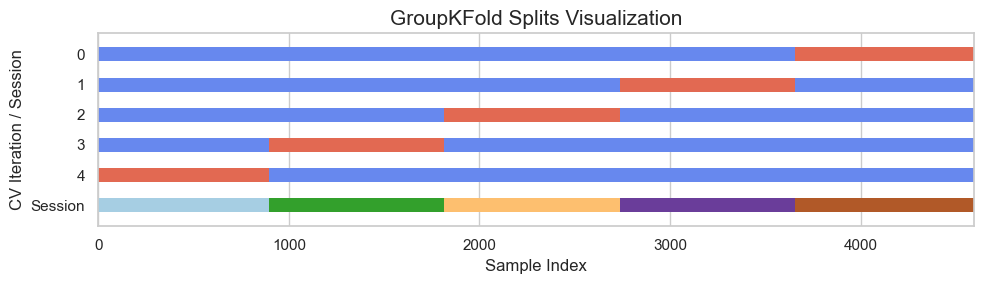

In [12]:
# %% [markdown]
# ## 6. Cross-Validation Strategy (Objective 3)
# (No changes needed here, use the cell from the original code)

# %%
N_SPLITS = N_SESSIONS_TRAIN_VAL # Use Leave-One-Session-Out
cv_strategy = GroupKFold(n_splits=N_SPLITS)
print(f"Using GroupKFold with {N_SPLITS} splits (Leave-One-Session-Out).")

# (plot_cv_indices function definition is the same as before)
def plot_cv_indices(cv, X, y, group, n_splits):
    fig, ax = plt.subplots(1, 1, figsize=(10, 3))
    cmap_data = plt.cm.Paired; cmap_cv = plt.cm.coolwarm
    # Generate splits and plot
    for i, (train_idx, test_idx) in enumerate(cv.split(X, y, group)):
        indices = np.array([np.nan] * len(X)); indices[test_idx] = 1; indices[train_idx] = 0
        # Plotting the splits for each CV iteration
        ax.scatter(range(len(indices)), [i + .5] * len(indices), c=indices, marker='_', lw=10, cmap=cmap_cv, vmin=-.2, vmax=1.2)
    # Plotting the session groups
    ax.scatter(range(len(X)), [i + 1.5] * len(X), c=group, marker='_', lw=10, cmap=cmap_data)
    # Formatting the plot
    yticklabels = list(range(n_splits)) + ['Session']
    ax.set(yticks=np.arange(n_splits + 1) + .5, yticklabels=yticklabels, xlabel='Sample Index', ylabel="CV Iteration / Session", ylim=[n_splits + 1.2, -.2], xlim=[0, len(y)])
    ax.set_title('GroupKFold Splits Visualization', fontsize=15); plt.tight_layout(); plt.show()

# Plot for our setup using the generated features X_features
# Check if X_features is defined and not empty
if 'X_features' in locals() and X_features.size > 0:
    plot_cv_indices(cv_strategy, X_features, y_windowed, groups, N_SPLITS)
else:
    print("Skipping CV plot: X_features not available or empty.")


In [13]:
# %% [markdown]
# ## 7. Baseline Model Training and Evaluation (Objective 4 - Part 1: All Features)
#
# Evaluate Ridge, Lasso, and Random Forest regressors using *all* extracted time-domain features. The pipeline includes the **corrected** feature extractor and scaling.

# %%
# Define Performance Metrics (No changes needed here)
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.maximum(mean_squared_error(y_true, y_pred), 0))

def normalized_mean_squared_error(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    if y_true.shape != y_pred.shape: raise ValueError("Shape mismatch")
    if y_true.ndim == 1: y_true, y_pred = y_true.reshape(-1, 1), y_pred.reshape(-1, 1)
    numerator = np.sum((y_true - y_pred)**2)
    mean_y_true_per_joint = np.mean(y_true, axis=0, keepdims=True)
    denominator = np.sum((y_true - mean_y_true_per_joint)**2)
    if denominator < 1e-9: return 0.0 if numerator < 1e-9 else np.inf
    else: return numerator / denominator

scorers = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'nmse': make_scorer(normalized_mean_squared_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}
print("Scorers defined: RMSE (neg), NMSE (neg), R2.")

# %%
# Select Baseline Models (No changes needed here)
model_ridge = Ridge(alpha=1.0)
model_lasso = Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42)
model_rf = RandomForestRegressor(
    n_estimators=100, max_depth=15, n_jobs=-1, random_state=42,
    max_features=0.33, min_samples_leaf=5
)

baseline_models_to_evaluate = {
    "Ridge": model_ridge,
    "Lasso": model_lasso,
    "RandomForest": model_rf
}

all_cv_results = {} # Reset results
results_summary_list = [] # Reset summary


# %%
# Evaluate baseline models using Cross-Validation with ALL features
print("--- Evaluating Baseline Models (Ridge, Lasso, RF) with ALL Features (Corrected Extractor) ---")

cv_params = {'groups': groups}

for model_name, model in baseline_models_to_evaluate.items():
    with timer(f"Cross-validating {model_name} (all features)"):
        # Pipeline: Use the CORRECTED EMGFeatureExtractor -> Scale -> Regress
        pipeline = Pipeline([
            ('feature_extraction', EMGFeatureExtractor()), # Uses default (all) features implicitly
            ('scaling', StandardScaler()),
            ('regression', model)
        ])

        # Perform cross-validation (using the same try/except logic for compatibility)
        try:
             scores = cross_validate(
                 pipeline, X_windowed, y_windowed, cv=cv_strategy,
                 scoring=scorers, n_jobs=-1, return_train_score=False,
                 params=cv_params, error_score='raise'
             )
        except TypeError as e:
             if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed, passing groups directly to cv.split()...")
                fold_scores = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_windowed, y_windowed, groups=groups)):
                    start_fit_time = time.time()
                    pipeline.fit(X_windowed[train_idx], y_windowed[train_idx])
                    end_fit_time = time.time()
                    y_pred = pipeline.predict(X_windowed[test_idx])
                    end_score_time = time.time()
                    fold_scores['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                         score_value = scorer_func(pipeline, X_windowed[test_idx], y_windowed[test_idx])
                         fold_scores[score_name].append(score_value)
                scores = {f"test_{key}": np.array(values) for key, values in fold_scores.items() if key in scorers}
                scores['fit_time'] = np.array(fold_scores['fit_time'])
                scores['score_time'] = np.array(fold_scores['score_time'])
             else: raise e

        all_cv_results[model_name] = scores # Store results

# %%
# Display Baseline CV Results (All Features) - Copied cell, should work now
print("\nBaseline Cross-Validation Performance Results (All Features):")

for model_name, scores in all_cv_results.items():
     if model_name in baseline_models_to_evaluate:
        mean_rmse = -np.nanmean(scores['test_rmse'])
        std_rmse = np.nanstd(scores['test_rmse'])
        mean_nmse = -np.nanmean(scores['test_nmse'])
        std_nmse = np.nanstd(scores['test_nmse'])
        mean_r2 = np.nanmean(scores['test_r2'])
        std_r2 = np.nanstd(scores['test_r2'])
        fit_time_mean = np.nanmean(scores['fit_time'])
        score_time_mean = np.nanmean(scores['score_time'])

        print(f"\n--- {model_name} (All Features) ---")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Fit Time: {fit_time_mean:.2f}s")
        print(f"  Avg Score Time: {score_time_mean:.2f}s")

        results_summary_list.append({
            'Model': model_name, 'Type': 'Baseline_AllFeat',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

results_df = pd.DataFrame(results_summary_list)
print("\n--- Baseline Summary Table (All Features) ---")
# Ensure the DataFrame is not empty before filtering/printing
if not results_df.empty:
     print(results_df[results_df['Type'] == 'Baseline_AllFeat'].to_string(index=False, float_format="%.4f"))
else:
     print("Results DataFrame is empty.")


# %% [markdown]
# **Interpretation (All Features):**
# (No changes needed here)

Scorers defined: RMSE (neg), NMSE (neg), R2.
--- Evaluating Baseline Models (Ridge, Lasso, RF) with ALL Features (Corrected Extractor) ---
Cross-validating Ridge (all features)...
Cross-validating Ridge (all features) done in 40.85 seconds.

Cross-validating Lasso (all features)...
Cross-validating Lasso (all features) done in 43.35 seconds.

Cross-validating RandomForest (all features)...
Cross-validating RandomForest (all features) done in 62.34 seconds.


Baseline Cross-Validation Performance Results (All Features):

--- Ridge (All Features) ---
  RMSE: 7.3099 +/- 0.5291
  NMSE: 0.2665 +/- 0.0448
  R2 Score: 0.5817 +/- 0.0828
  Avg Fit Time: 12.34s
  Avg Score Time: 2.67s

--- Lasso (All Features) ---
  RMSE: 7.2993 +/- 0.5237
  NMSE: 0.2657 +/- 0.0441
  R2 Score: 0.5387 +/- 0.0862
  Avg Fit Time: 32.57s
  Avg Score Time: 3.33s

--- RandomForest (All Features) ---
  RMSE: 4.7953 +/- 0.8263
  NMSE: 0.1176 +/- 0.0447
  R2 Score: 0.6999 +/- 0.0724
  Avg Fit Time: 56.00s
  Avg Score Tim


--- Random Forest Feature Importance Analysis (Full Data - for Insight) ---
Extracting & Scaling features for Full Importance Analysis...
Extracting & Scaling features for Full Importance Analysis done in 7.64 seconds.

Training RandomForest on full scaled data for Importance Plot...
Training RandomForest on full scaled data for Importance Plot done in 6.86 seconds.


Random Forest Feature Importances (Top 30 - based on full data):


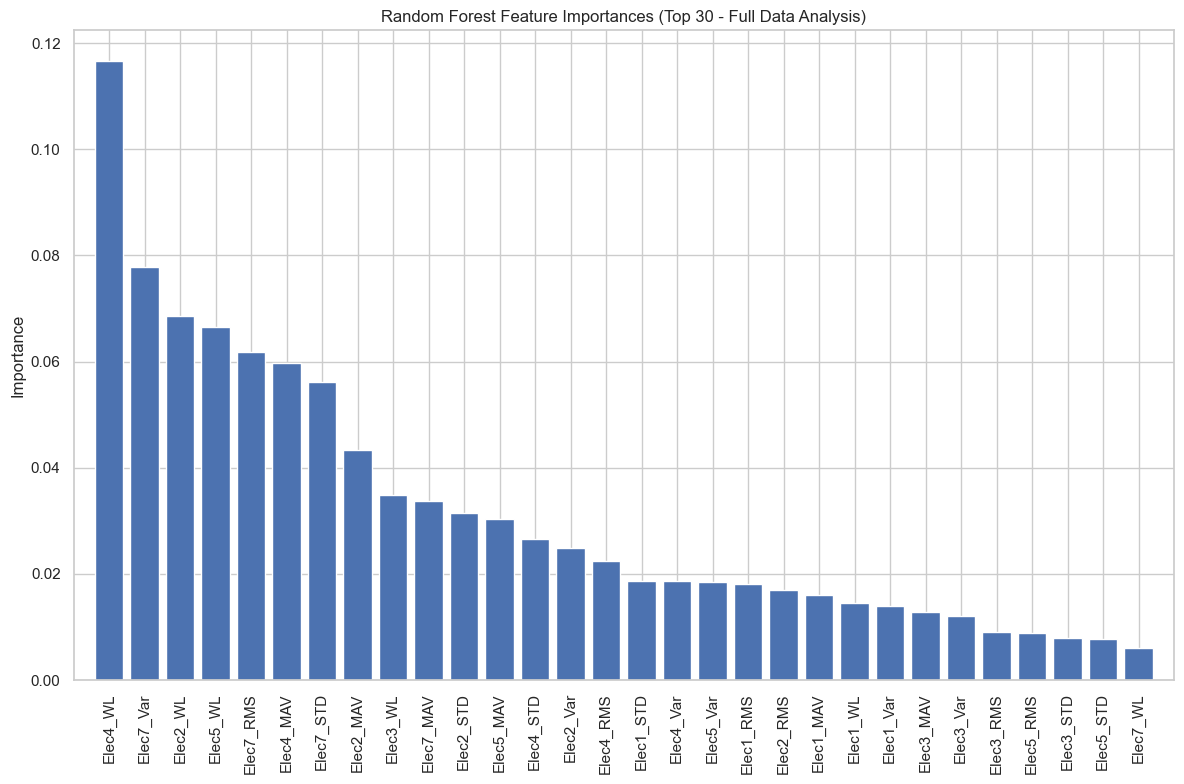


--- Evaluating Models with Integrated Feature Selection (Nested CV Approach - Expanded) ---

--- Processing Fold 1/5 for Integrated Feature Selection ---
  Fold 1: Feature Extraction...
  Fold 1: Feature Extraction done in 4.20 seconds.

  Fold 1: Scaling...
  Fold 1: Scaling done in 0.01 seconds.

  Fold 1: RFECV (estimator=Ridge, n_jobs=1)...
    RFECV selected 64 features.
  Fold 1: RFECV (estimator=Ridge, n_jobs=1) done in 0.40 seconds.

  Fold 1: Importance Selection (estimator=RF)...
    Importance selected top 32 features.
  Fold 1: Importance Selection (estimator=RF) done in 2.10 seconds.

  Fold 1: Evaluating Ridge with RFECV features (64)...
    Ridge_RFECV - RMSE: 7.0020, NMSE: 0.2332, R2: 0.6460
  Fold 1: Evaluating Ridge with RFECV features (64) done in 0.02 seconds.

  Fold 1: Evaluating RF with Importance features (32)...
    RF_Importance - RMSE: 4.4007, NMSE: 0.0921, R2: 0.7546
  Fold 1: Evaluating RF with Importance features (32) done in 3.17 seconds.

  Fold 1: Eval

In [16]:
from sklearn.base import BaseEstimator, TransformerMixin, clone # <--- ADD clone HERE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler # Key for preprocessing features

# %% [markdown]
# ## 8. Feature Importance Analysis and Integrated Selection (Objective 4 - Part 2: Selection)
#
# We now perform feature selection *correctly integrated within the cross-validation loop* to avoid data leakage. We will evaluate models using features selected by RFECV and Importance Thresholding within each fold.
#
# **Note:** Feature importance analysis (like the RF plot) can still be done on the full dataset for *understanding*, but the selection for *evaluation* must happen inside CV folds.

# %%
# --- Feature Importance Analysis (using RF trained on full data - for insight only) ---
print("\n--- Random Forest Feature Importance Analysis (Full Data - for Insight) ---")
# Need scaled features for analysis consistency
analysis_pipeline_full = Pipeline([
    ('feature_extraction', EMGFeatureExtractor()),
    ('scaling', StandardScaler())
])

with timer("Extracting & Scaling features for Full Importance Analysis"):
    X_features_scaled_full = analysis_pipeline_full.fit_transform(X_windowed, y_windowed)
    feature_names_full = analysis_pipeline_full.named_steps['feature_extraction'].get_feature_names_out()

# Train RF on the fully scaled data ONLY for this analysis plot
with timer("Training RandomForest on full scaled data for Importance Plot"):
    model_rf_analysis = RandomForestRegressor(
        n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
    )
    model_rf_analysis.fit(X_features_scaled_full, y_windowed)

# Get and plot feature importances
importances_full = model_rf_analysis.feature_importances_
indices_full = np.argsort(importances_full)[::-1]
print("\nRandom Forest Feature Importances (Top 30 - based on full data):")
n_top_features_plot = 30
plt.figure(figsize=(12, 8))
plt.title("Random Forest Feature Importances (Top 30 - Full Data Analysis)")
top_indices = indices_full[:n_top_features_plot]
plt.bar(range(len(top_indices)), importances_full[top_indices], align='center')
plt.xticks(range(len(top_indices)), [feature_names_full[i] for i in top_indices], rotation=90)
plt.xlim([-1, len(top_indices)]); plt.ylabel("Importance"); plt.tight_layout(); plt.show()
# --- End of Analysis Plot Section ---


# %% [markdown]
# ### 8.1 Cross-Validation with Integrated Feature Selection (Expanded)
#
# Evaluate combinations: Ridge+RFECV, RF+Importance, **Ridge+Importance**, **RF+RFECV**.
# **Note:** RFECV will run with n_jobs=1 to avoid pickling errors, making it slower.

# %%
print("\n--- Evaluating Models with Integrated Feature Selection (Nested CV Approach - Expanded) ---")

# RFECV Settings
MIN_FEATURES_RFECV = 10
STEP_RFECV = 5
CV_INNER_RFECV = 3 # Keep inner CV folds lower for speed

# Importance Thresholding Settings
N_FEATURES_IMPORTANCE = 32 # Number of top features from RF

# Store results for models with feature selection
fs_results = {
    # Original pairs
    "Ridge_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    "RF_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    # Added pairs
    "Ridge_Importance": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
    "RF_RFECV": {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': [], 'n_features': []},
}

# Define models needed for evaluation (final step)
model_ridge_final = Ridge(alpha=1.0)
model_rf_final = RandomForestRegressor(
            n_estimators=100, max_depth=15, n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
        )
# Define models needed for selection steps
model_ridge_for_rfecv = Ridge(alpha=1.0)
model_rf_for_importance = RandomForestRegressor( # Faster RF for importance calculation
                n_estimators=50, max_depth=10,
                n_jobs=-1, random_state=42, max_features=0.33, min_samples_leaf=5
            )


fold_num = 0
feature_extractor_cv = EMGFeatureExtractor() # Instantiate once outside loop

# Outer CV Loop (LOSO)
for train_idx, test_idx in cv_strategy.split(X_windowed, y_windowed, groups=groups):
    fold_num += 1
    print(f"\n--- Processing Fold {fold_num}/{N_SPLITS} for Integrated Feature Selection ---")
    start_fold_time = time.time()

    # 1. Split raw windowed data
    X_train_fold_raw, X_test_fold_raw = X_windowed[train_idx], X_windowed[test_idx]
    y_train_fold, y_test_fold = y_windowed[train_idx], y_windowed[test_idx]

    # 2. Extract features on fold data
    with timer(f"  Fold {fold_num}: Feature Extraction"):
        X_train_features = feature_extractor_cv.transform(X_train_fold_raw)
        X_test_features = feature_extractor_cv.transform(X_test_fold_raw)
        if fold_num == 1: feature_names = feature_extractor_cv.get_feature_names_out()

    # 3. Scale features (fit on train, transform train & test)
    with timer(f"  Fold {fold_num}: Scaling"):
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_features)
        X_test_scaled = scaler.transform(X_test_features)

    # --- Feature Selection Step (on Fold's Training Data) ---
    selected_indices_rfecv = None
    n_features_rfecv = X_train_scaled.shape[1]
    selected_indices_importance = None
    n_features_importance = X_train_scaled.shape[1]

    # 4a. RFECV with Ridge (n_jobs=1)
    with timer(f"  Fold {fold_num}: RFECV (estimator=Ridge, n_jobs=1)"): # Slow step
        try:
            rfecv_selector = RFECV(
                estimator=clone(model_ridge_for_rfecv), # Clone estimator
                step=STEP_RFECV, cv=CV_INNER_RFECV, scoring=scorers['rmse'],
                min_features_to_select=MIN_FEATURES_RFECV,
                n_jobs=1 # Set n_jobs=1 to avoid pickling issues
            )
            rfecv_selector.fit(X_train_scaled, y_train_fold)
            selected_indices_rfecv = rfecv_selector.support_
            n_features_rfecv = rfecv_selector.n_features_
            print(f"    RFECV selected {n_features_rfecv} features.")
        except Exception as e:
            print(f"    RFECV failed for Fold {fold_num}: {e}. Using all features.")
            selected_indices_rfecv = np.ones(X_train_scaled.shape[1], dtype=bool)

    # 4b. Importance Thresholding with RandomForest
    with timer(f"  Fold {fold_num}: Importance Selection (estimator=RF)"):
        try:
            rf_importance_model = clone(model_rf_for_importance) # Clone estimator
            rf_importance_model.fit(X_train_scaled, y_train_fold)
            importances = rf_importance_model.feature_importances_
            indices_sorted = np.argsort(importances)[::-1]
            selected_indices_importance = np.zeros(X_train_scaled.shape[1], dtype=bool)
            n_select = min(N_FEATURES_IMPORTANCE, X_train_scaled.shape[1])
            selected_indices_importance[indices_sorted[:n_select]] = True
            n_features_importance = n_select
            print(f"    Importance selected top {n_features_importance} features.")
        except Exception as e:
            print(f"    Importance selection failed for Fold {fold_num}: {e}. Using all features.")
            selected_indices_importance = np.ones(X_train_scaled.shape[1], dtype=bool)


    # --- Model Evaluation Step (using selected features) ---
    # Helper function for evaluation to reduce repetition
    def evaluate_model(model_key, model_instance, X_train, y_train, X_test, y_test, selected_indices, n_features):
        if selected_indices is None or not np.any(selected_indices): # Check if selection failed or returned empty
             print(f"    Skipping {model_key} evaluation due to invalid feature indices.")
             # Append NaN or handle appropriately
             fs_results[model_key]['test_rmse'].append(np.nan)
             fs_results[model_key]['test_nmse'].append(np.nan)
             fs_results[model_key]['test_r2'].append(np.nan)
             fs_results[model_key]['n_features'].append(X_train.shape[1]) # Record original count if failed
             return

        X_train_sel = X_train[:, selected_indices]
        X_test_sel = X_test[:, selected_indices]
        model_instance = clone(model_instance) # Clone before fitting
        model_instance.fit(X_train_sel, y_train)
        y_pred = model_instance.predict(X_test_sel)
        rmse = root_mean_squared_error(y_test, y_pred)
        nmse = normalized_mean_squared_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        fs_results[model_key]['test_rmse'].append(-rmse)
        fs_results[model_key]['test_nmse'].append(-nmse)
        fs_results[model_key]['test_r2'].append(r2)
        fs_results[model_key]['n_features'].append(n_features)
        print(f"    {model_key} - RMSE: {rmse:.4f}, NMSE: {nmse:.4f}, R2: {r2:.4f}")

    fold_fit_start_time = time.time()

    # 5a. Evaluate Ridge_RFECV
    with timer(f"  Fold {fold_num}: Evaluating Ridge with RFECV features ({n_features_rfecv})"):
        evaluate_model("Ridge_RFECV", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)

    # 5b. Evaluate RF_Importance
    with timer(f"  Fold {fold_num}: Evaluating RF with Importance features ({n_features_importance})"):
        evaluate_model("RF_Importance", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)

    # 5c. Evaluate Ridge_Importance
    with timer(f"  Fold {fold_num}: Evaluating Ridge with Importance features ({n_features_importance})"):
        evaluate_model("Ridge_Importance", model_ridge_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_importance, n_features_importance)

    # 5d. Evaluate RF_RFECV
    with timer(f"  Fold {fold_num}: Evaluating RF with RFECV features ({n_features_rfecv})"):
        evaluate_model("RF_RFECV", model_rf_final, X_train_scaled, y_train_fold, X_test_scaled, y_test_fold, selected_indices_rfecv, n_features_rfecv)

    # Record Timings
    fold_end_time = time.time()
    total_fold_time = fold_end_time - start_fold_time
    # Assign total time to all models evaluated in this fold (approximation)
    for key in ["Ridge_RFECV", "RF_Importance", "Ridge_Importance", "RF_RFECV"]:
        fs_results[key]['fit_time'].append(total_fold_time)
        fs_results[key]['score_time'].append(0) # Scoring integrated

# %%
# Aggregate and Display Results for Models with Integrated Feature Selection (Expanded)
# (Cell for displaying results is largely the same, just iterates through the updated fs_results)
print("\n--- Performance Results (Integrated Feature Selection - Expanded) ---")

# Need to check if results list exists and is populated
if 'results_summary_list' not in locals():
     results_summary_list = [] # Initialize if it doesn't exist

# Remove previous FS results before adding new ones, if script is re-run
results_summary_list = [item for item in results_summary_list if item['Type'] != 'Baseline_FS']


for model_fs_name, scores in fs_results.items():
    # Check if score lists are empty before calculating mean/std
    if not scores['test_rmse']:
        print(f"Warning: No scores recorded for {model_fs_name}. Skipping summary.")
        continue

    mean_rmse = -np.nanmean(scores['test_rmse'])
    std_rmse = np.nanstd(scores['test_rmse'])
    mean_nmse = -np.nanmean(scores['test_nmse'])
    std_nmse = np.nanstd(scores['test_nmse'])
    mean_r2 = np.nanmean(scores['test_r2'])
    std_r2 = np.nanstd(scores['test_r2'])
    fit_time_mean = np.nanmean(scores['fit_time'])
    avg_n_features = np.nanmean(scores['n_features'])
    std_n_features = np.nanstd(scores['n_features'])

    print(f"\n--- {model_fs_name} ---")
    print(f"  Avg. Features Selected: {avg_n_features:.1f} +/- {std_n_features:.1f}")
    print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
    print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
    print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
    print(f"  Avg Total Time per Fold: {fit_time_mean:.2f}s")

    # Add to summary list for final table
    results_summary_list.append({
        'Model': model_fs_name, 'Type': 'Baseline_FS',
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

# Update and display the comparison table including expanded FS results
results_df = pd.DataFrame(results_summary_list)
print("\n--- Updated Summary Table (Including Expanded Integrated FS) ---")
if not results_df.empty:
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Results DataFrame is empty.")

# Clean up large intermediate variables if memory is a concern
# del X_train_features, X_test_features, X_train_scaled, X_test_scaled
# gc.collect() # Already done later

In [17]:

# %% [markdown]
# ## 9. Sophisticated Approach: Neural Network (Objective 5) - *No changes needed here*
#
# Implement and evaluate the MLP using PyTorch, performing cross-validation manually with scaling inside the loop.

# %%
# Define the Neural Network Architecture (Copied from original GEGE)
class EMG_NN(nn.Module):
    def __init__(self, n_features, n_joints, hidden_dim1=128, hidden_dim2=64, dropout_p=0.3):
        super(EMG_NN, self).__init__()
        self.layer_1 = nn.Linear(n_features, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.batchnorm1 = nn.BatchNorm1d(hidden_dim1) # Added BatchNorm
        self.dropout1 = nn.Dropout(dropout_p)
        self.layer_2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.batchnorm2 = nn.BatchNorm1d(hidden_dim2) # Added BatchNorm
        self.dropout2 = nn.Dropout(dropout_p)
        self.output_layer = nn.Linear(hidden_dim2, n_joints)

    def forward(self, x):
        x = self.dropout1(self.relu1(self.batchnorm1(self.layer_1(x))))
        x = self.dropout2(self.relu2(self.batchnorm2(self.layer_2(x))))
        x = self.output_layer(x)
        return x

# %%
# Training and Evaluation Functions for PyTorch NN (Copied from original GEGE)

def train_nn_epoch(model, dataloader, criterion, optimizer, device):
    model.train() # Set model to training mode
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad() # Zero gradients
        outputs = model(inputs) # Forward pass
        loss = criterion(outputs, targets) # Calculate loss
        loss.backward() # Backward pass
        optimizer.step() # Update weights
        running_loss += loss.item() * inputs.size(0) # Accumulate loss

    return running_loss / len(dataloader.dataset) # Return average loss for the epoch

def evaluate_nn_model(model, dataloader, criterion, device):
    model.eval() # Set model to evaluation mode
    running_loss = 0.0
    all_preds = []
    all_targets = []
    with torch.no_grad(): # Disable gradient calculations
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs) # Forward pass
            loss = criterion(outputs, targets) # Calculate loss
            running_loss += loss.item() * inputs.size(0) # Accumulate loss
            all_preds.append(outputs.cpu().numpy()) # Collect predictions (move back to CPU)
            all_targets.append(targets.cpu().numpy()) # Collect targets

    avg_loss = running_loss / len(dataloader.dataset)
    # Concatenate predictions and targets from all batches
    predictions = np.concatenate(all_preds)
    true_values = np.concatenate(all_targets)
    return avg_loss, predictions, true_values

# %%
# Manual Cross-Validation Loop for Neural Network (Copied from original GEGE)

# Hyperparameters
N_EPOCHS = 75 # Adjust as needed based on convergence
BATCH_SIZE = 64
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5 # L2 regularization for Adam

# NN requires features as input, use the full feature set generated earlier
# Ensure X_features (all features) and feature_names are available
if 'X_features' not in locals() or 'feature_names' not in locals():
     raise RuntimeError("X_features or feature_names not available for NN CV. Rerun feature extraction.")
X_input_for_nn_cv = X_features # Use the matrix with all features
n_input_features = X_input_for_nn_cv.shape[1]

nn_cv_scores = {'test_rmse': [], 'test_nmse': [], 'test_r2': [], 'fit_time': [], 'score_time': []}
print(f"\n--- Evaluating Neural Network (Manual CV, Input Features: {n_input_features}) ---")

fold_num = 0
for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
    fold_num += 1
    print(f"\nStarting NN CV Fold {fold_num}/{N_SPLITS}")
    start_fold_time = time.time()

    # 1. Split feature data for this fold
    X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
    y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx]

    # 2. Scale features based *only* on training data for this fold
    scaler_nn_fold = StandardScaler()
    X_train_fold_scaled = scaler_nn_fold.fit_transform(X_train_fold)
    X_val_fold_scaled = scaler_nn_fold.transform(X_val_fold) # Use same scaler for validation

    # 3. Create PyTorch Datasets and DataLoaders
    train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

    # 4. Initialize model, loss, optimizer for this fold
    model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
    criterion = nn.MSELoss() # Use MSE for regression
    optimizer = optim.Adam(model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    # Optional: Add a learning rate scheduler
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, verbose=True)


    # 5. Training loop with validation loss monitoring
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience = 15 # For early stopping based on validation loss

    print(f"Fold {fold_num}: Training for up to {N_EPOCHS} epochs...")
    for epoch in range(N_EPOCHS):
        train_loss = train_nn_epoch(model_nn, train_loader, criterion, optimizer, device)
        val_loss_epoch, _, _ = evaluate_nn_model(model_nn, val_loader, criterion, device)

        if (epoch + 1) % 10 == 0 or epoch == N_EPOCHS - 1:
             print(f'  Epoch {epoch+1}/{N_EPOCHS}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss_epoch:.6f}')

        # Update LR scheduler
        scheduler.step(val_loss_epoch)

        # Early Stopping Check
        if val_loss_epoch < best_val_loss:
             best_val_loss = val_loss_epoch
             epochs_no_improve = 0
             # Optional: Save the best model state for this fold
             # torch.save(model_nn.state_dict(), f'best_model_fold_{fold_num}.pth')
        else:
             epochs_no_improve += 1

        if epochs_no_improve >= patience:
             print(f"  Early stopping triggered at epoch {epoch + 1}")
             break

    fit_end_time = time.time()
    # Optional: Load the best model state if saved

    # 6. Evaluate on validation set
    print(f"Fold {fold_num}: Evaluating on validation set...")
    val_loss, y_pred_fold, y_true_fold = evaluate_nn_model(model_nn, val_loader, criterion, device)
    score_end_time = time.time()

    # 7. Calculate and store metrics for this fold
    rmse_fold = root_mean_squared_error(y_true_fold, y_pred_fold)
    nmse_fold = normalized_mean_squared_error(y_true_fold, y_pred_fold)
    r2_fold = r2_score(y_true_fold, y_pred_fold)

    nn_cv_scores['test_rmse'].append(-rmse_fold) # Store negative for consistency with scorers
    nn_cv_scores['test_nmse'].append(-nmse_fold)
    nn_cv_scores['test_r2'].append(r2_fold)
    nn_cv_scores['fit_time'].append(fit_end_time - start_fold_time)
    nn_cv_scores['score_time'].append(score_end_time - fit_end_time)

    print(f"Fold {fold_num} Metrics: RMSE={rmse_fold:.4f}, NMSE={nmse_fold:.4f}, R2={r2_fold:.4f}")
    # Clean up GPU memory if needed
    del model_nn, train_loader, val_loader, train_dataset, val_dataset
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    gc.collect()


# Store overall NN results
all_cv_results["NeuralNetwork"] = nn_cv_scores

# %%
# Add NN results to the summary DataFrame
nn_model_name = "NeuralNetwork"
if nn_model_name in all_cv_results: # Check if NN ran successfully
    nn_scores = all_cv_results[nn_model_name]
    mean_rmse = -np.nanmean(nn_scores['test_rmse'])
    std_rmse = np.nanstd(nn_scores['test_rmse'])
    mean_nmse = -np.nanmean(nn_scores['test_nmse'])
    std_nmse = np.nanstd(nn_scores['test_nmse'])
    mean_r2 = np.nanmean(nn_scores['test_r2'])
    std_r2 = np.nanstd(nn_scores['test_r2'])
    fit_time_mean = np.nanmean(nn_scores['fit_time'])
    # score_time_mean = np.nanmean(nn_scores['score_time']) # Score time seems less relevant here

    results_summary_list.append({
        'Model': nn_model_name, 'Type': 'Sophisticated',
        'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
        'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
        'R2_mean': mean_r2, 'R2_std': std_r2,
        'FitTime': fit_time_mean
    })

    # Update and display the final comparison table
    results_df = pd.DataFrame(results_summary_list)
    print("\n--- Combined Model Comparison Table (incl. NN) ---")
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Neural Network results not found in all_cv_results.")



--- Evaluating Neural Network (Manual CV, Input Features: 64) ---

Starting NN CV Fold 1/5


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Fold 1: Training for up to 75 epochs...
  Epoch 10/75, Train Loss: 102.989339, Val Loss: 95.436647
  Epoch 20/75, Train Loss: 47.381003, Val Loss: 39.180908
  Epoch 30/75, Train Loss: 34.793181, Val Loss: 22.624749
  Epoch 40/75, Train Loss: 29.952407, Val Loss: 18.947204
  Epoch 50/75, Train Loss: 29.660116, Val Loss: 18.784088
  Epoch 60/75, Train Loss: 27.245535, Val Loss: 18.760714
  Epoch 70/75, Train Loss: 27.596532, Val Loss: 15.872943
  Epoch 75/75, Train Loss: 26.251769, Val Loss: 16.080342
Fold 1: Evaluating on validation set...
Fold 1 Metrics: RMSE=4.0100, NMSE=0.0765, R2=-28679358.0000

Starting NN CV Fold 2/5
Fold 2: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/75, Train Loss: 107.773118, Val Loss: 98.895191
  Epoch 20/75, Train Loss: 49.807629, Val Loss: 35.614250
  Epoch 30/75, Train Loss: 33.258035, Val Loss: 19.376721
  Epoch 40/75, Train Loss: 31.229826, Val Loss: 16.766734
  Epoch 50/75, Train Loss: 29.665287, Val Loss: 15.227908
  Epoch 60/75, Train Loss: 28.526462, Val Loss: 14.213011
  Epoch 70/75, Train Loss: 26.921339, Val Loss: 14.733882
  Epoch 75/75, Train Loss: 27.184886, Val Loss: 13.733518
Fold 2: Evaluating on validation set...
Fold 2 Metrics: RMSE=3.7059, NMSE=0.0696, R2=-24037398.0000

Starting NN CV Fold 3/5
Fold 3: Training for up to 75 epochs...


...

  Epoch 10/75, Train Loss: 106.839739, Val Loss: 103.516644
  Epoch 20/75, Train Loss: 49.303918, Val Loss: 46.307910
  Epoch 30/75, Train Loss: 33.174186, Val Loss: 28.259187
  Epoch 40/75, Train Loss: 29.313892, Val Loss: 25.127920
  Epoch 50/75, Train Loss: 28.077176, Val Loss: 23.623860
  Early stopping triggered at epoch 51
Fold 3: Evaluating on validation set...
Fold 3 Metrics: RMSE=5.0655, NMSE=0.1205, R2=-29440666.0000

Starting NN CV Fold 4/5
Fold 4: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/75, Train Loss: 105.761384, Val Loss: 99.580172
  Epoch 20/75, Train Loss: 47.294839, Val Loss: 40.283934
  Epoch 30/75, Train Loss: 33.781342, Val Loss: 26.989754
  Epoch 40/75, Train Loss: 30.145356, Val Loss: 25.418542
  Epoch 50/75, Train Loss: 29.167832, Val Loss: 21.122990
  Epoch 60/75, Train Loss: 28.205098, Val Loss: 22.463307
  Epoch 70/75, Train Loss: 27.857224, Val Loss: 20.134411
  Epoch 75/75, Train Loss: 26.608892, Val Loss: 24.039793
Fold 4: Evaluating on validation set...
Fold 4 Metrics: RMSE=4.9030, NMSE=0.1222, R2=-25045888.0000

Starting NN CV Fold 5/5
Fold 5: Training for up to 75 epochs...


c:\Users\Asus\OneDrive - Université Libre de Bruxelles\Documents\Cours\MA3\Q2\ML\Project\guided\.venv\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


  Epoch 10/75, Train Loss: 106.940145, Val Loss: 102.150060
  Epoch 20/75, Train Loss: 47.392900, Val Loss: 52.600792
  Epoch 30/75, Train Loss: 33.868750, Val Loss: 33.347936
  Epoch 40/75, Train Loss: 29.337924, Val Loss: 37.709895
  Epoch 50/75, Train Loss: 28.829893, Val Loss: 26.758898
  Epoch 60/75, Train Loss: 27.257899, Val Loss: 23.273495
  Epoch 70/75, Train Loss: 27.716234, Val Loss: 24.622857
  Epoch 75/75, Train Loss: 28.073694, Val Loss: 24.081554
Fold 5: Evaluating on validation set...
Fold 5 Metrics: RMSE=4.9073, NMSE=0.1242, R2=-32759132.0000

--- Combined Model Comparison Table (incl. NN) ---
           Model             Type  RMSE_mean  RMSE_std  NMSE_mean  NMSE_std        R2_mean       R2_std  FitTime
   NeuralNetwork    Sophisticated     4.5183    0.5508     0.1026    0.0243 -27992488.4000 3150082.3293 728.4825
    RandomForest Baseline_AllFeat     4.7953    0.8263     0.1176    0.0447         0.6999       0.0724  56.0015
        RF_RFECV      Baseline_FS     4.795

In [23]:
# %% [markdown]
# ## 10. Objective 6: Ensembling Strategies
#
# Implement Averaging and Stacking ensembles using the out-of-fold predictions from the baseline models (using all features) and the Neural Network.

# %% [markdown]
# ### 10.1 Generate Out-of-Fold (OOF) Predictions
#
# Get OOF predictions for models intended for ensembling (typically the best performing variations). We'll use the baseline models trained on ALL features and the Neural Network.

# %%
oof_predictions = {} # Dictionary to store OOF predictions

# --- OOF Predictions for Baseline Models (All Features) ---
print("--- Generating OOF Predictions for Baseline Models (All Features) ---")
baseline_pipelines_oof = {}
# Use the models defined in baseline_models_to_evaluate
for model_name, model in baseline_models_to_evaluate.items():
     baseline_pipelines_oof[model_name] = Pipeline([
          ('feature_extraction', EMGFeatureExtractor()), # All features
          ('scaling', StandardScaler()),
          ('regression', model)
     ])

# Use cross_val_predict
for model_name, pipeline in baseline_pipelines_oof.items():
     with timer(f"Generating OOF predictions for {model_name}"):
          try:
               # Try with metadata routing first
               oof_preds = cross_val_predict(
                   pipeline, X_windowed, y_windowed, cv=cv_strategy,
                   n_jobs=-1, method='predict', params={'groups': groups}
               )
          except TypeError as e:
               # Fallback if metadata routing fails
               if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                    print("Metadata routing failed for cross_val_predict, using manual loop...")
                    oof_preds_list = [None] * len(X_windowed)
                    for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_windowed, y_windowed, groups=groups)):
                        pipeline.fit(X_windowed[train_idx], y_windowed[train_idx])
                        fold_preds = pipeline.predict(X_windowed[test_idx])
                        for i, idx in enumerate(test_idx):
                            oof_preds_list[idx] = fold_preds[i]
                    oof_preds = np.stack(oof_preds_list)
               else:
                   raise e
          oof_predictions[model_name] = oof_preds
     print(f"Shape of {model_name} OOF predictions: {oof_preds.shape}")

# --- OOF Predictions for Neural Network ---
print("\n--- Generating OOF Predictions for Neural Network (Manual CV - Reuse previous logic) ---")
# We need to run the manual CV loop again, focusing on collecting predictions

# Ensure NN hyperparameters are defined (consistency)
N_EPOCHS_OOF = 75 # Same number of epochs used in evaluation
BATCH_SIZE_OOF = 64
LEARNING_RATE_OOF = 0.001
WEIGHT_DECAY_OOF = 1e-5

nn_oof_preds_list = [None] * len(X_input_for_nn_cv) # List to store predictions
nn_indices_list = [] # To verify order

if 'X_input_for_nn_cv' not in locals() or X_input_for_nn_cv is None:
     raise ValueError("NN features (X_input_for_nn_cv) not found. Cannot generate OOF.")
n_input_features_oof = X_input_for_nn_cv.shape[1]

fold_num = 0
with timer("Generating OOF predictions for Neural Network (Manual CV)"):
    for train_idx, val_idx in cv_strategy.split(X_input_for_nn_cv, y_windowed, groups=groups):
        fold_num += 1
        if fold_num % 2 == 0: print(f"  Processing NN OOF Fold {fold_num}/{N_SPLITS}") # Print progress less often

        # 1. Split data
        X_train_fold, X_val_fold = X_input_for_nn_cv[train_idx], X_input_for_nn_cv[val_idx]
        y_train_fold, y_val_fold = y_windowed[train_idx], y_windowed[val_idx]

        # 2. Scale features
        scaler_oof = StandardScaler()
        X_train_fold_scaled = scaler_oof.fit_transform(X_train_fold)
        X_val_fold_scaled = scaler_oof.transform(X_val_fold)

        # 3. Datasets & DataLoaders
        train_dataset = TensorDataset(torch.FloatTensor(X_train_fold_scaled), torch.FloatTensor(y_train_fold))
        val_dataset = TensorDataset(torch.FloatTensor(X_val_fold_scaled), torch.FloatTensor(y_val_fold))
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE_OOF, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE_OOF*2, shuffle=False) # Larger batch for eval

        # 4. Initialize model, loss, optimizer
        model_nn_oof = EMG_NN(n_features=n_input_features_oof, n_joints=N_JOINTS).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model_nn_oof.parameters(), lr=LEARNING_RATE_OOF, weight_decay=WEIGHT_DECAY_OOF)

        # 5. Training loop (no early stopping needed here, train for fixed epochs)
        for epoch in range(N_EPOCHS_OOF):
            _ = train_nn_epoch(model_nn_oof, train_loader, criterion, optimizer, device)

        # 6. Evaluate and GET PREDICTIONS on validation set
        _, y_pred_fold, _ = evaluate_nn_model(model_nn_oof, val_loader, criterion, device)

        # 7. Store predictions
        for i, idx in enumerate(val_idx):
            if idx < len(nn_oof_preds_list): # Boundary check
                 nn_oof_preds_list[idx] = y_pred_fold[i]
            else:
                 print(f"Warning: Index {idx} out of bounds for nn_oof_preds_list (size {len(nn_oof_preds_list)})")
        nn_indices_list.extend(val_idx.tolist())

        # Clean up
        del model_nn_oof, train_loader, val_loader, train_dataset, val_dataset
        if torch.cuda.is_available(): torch.cuda.empty_cache()
        gc.collect()


# Combine the list of predictions into a single numpy array
# Check if all predictions were filled
contains_none = any(pred is None for pred in nn_oof_preds_list)

if contains_none:
    print("Warning: Some NN OOF predictions are missing (None found). Filling with zeros.")
    # Find average prediction shape from non-None entries
    # Filter out None before checking shapes
    shapes = [p.shape for p in nn_oof_preds_list if p is not None]
    if not shapes:
        raise ValueError("Cannot determine NN prediction shape, all OOF preds are None.")
    avg_shape = shapes[0] # Assume consistent shape
    fill_value = np.zeros(avg_shape)
    # Fill None values correctly
    nn_oof_preds_filled = [p if p is not None else fill_value for p in nn_oof_preds_list]
    oof_predictions["NeuralNetwork"] = np.stack(nn_oof_preds_filled)
else:
     # If no None is found, stack directly
     oof_predictions["NeuralNetwork"] = np.stack(nn_oof_preds_list)


# Verification
print(f"Shape of NN OOF predictions: {oof_predictions['NeuralNetwork'].shape}")
# Ensure all models intended for ensembling have OOF predictions
ensemble_model_names = list(baseline_models_to_evaluate.keys()) + ["NeuralNetwork"]
missing_oof = [name for name in ensemble_model_names if name not in oof_predictions]
if missing_oof:
     raise RuntimeError(f"Missing OOF predictions for models: {missing_oof}")


# %% [markdown]
# ### 10.2 Averaging Ensemble
#
# Compute the simple average of the OOF predictions.

# %%
print("\n--- Evaluating Averaging Ensemble ---")
model_names_for_avg = list(oof_predictions.keys()) # Use all available OOF preds
print(f"Averaging predictions from models: {model_names_for_avg}")

# Summing up the predictions
oof_preds_sum = np.zeros_like(y_windowed, dtype=np.float64) # Use y_windowed shape/dtype
for model_name in model_names_for_avg:
    oof_preds_sum += oof_predictions[model_name]

# Calculating the average
oof_preds_avg = oof_preds_sum / len(model_names_for_avg)

# Evaluate the performance of the averaged predictions ONCE using the full OOF set
avg_rmse = root_mean_squared_error(y_windowed, oof_preds_avg)
avg_nmse = normalized_mean_squared_error(y_windowed, oof_preds_avg)
avg_r2 = r2_score(y_windowed, oof_preds_avg)

print(f"\nAveraging Ensemble Performance (on OOF predictions):")
print(f"  RMSE: {avg_rmse:.4f}")
print(f"  NMSE: {avg_nmse:.4f}")
print(f"  R2 Score: {avg_r2:.4f}")

# Add results to summary
results_summary_list.append({
    'Model': 'AverageEnsemble', 'Type': 'Ensemble',
    'RMSE_mean': avg_rmse, 'RMSE_std': np.nan, # No std dev from single OOF evaluation
    'NMSE_mean': avg_nmse, 'NMSE_std': np.nan,
    'R2_mean': avg_r2, 'R2_std': np.nan,
    'FitTime': np.nan # Fit time is combination of base models
})
# Update results_df
results_df = pd.DataFrame(results_summary_list)


# %% [markdown]
# ### 10.3 Stacking Ensemble (Meta-Learner - Expanded Evaluation)
#
# Train and evaluate different meta-learners (Ridge, Lasso, RandomForest)
# on the OOF predictions using cross-validation.

# %%
print("\n--- Evaluating Stacking Ensemble (Multiple Meta-Learners) ---")
# 1. Create Meta-Features (if not already created or cleared)
if 'X_meta' not in locals() or X_meta.shape[0] != len(y_windowed):
    print("Recreating meta-features...")
    model_names_for_stacking = list(oof_predictions.keys())
    X_meta_list = [oof_predictions[model_name] for model_name in model_names_for_stacking]
    try:
        X_meta = np.hstack(X_meta_list)
    except ValueError as e:
        print(f"Error stacking OOF predictions: {e}")
        raise e
    print(f"Shape of Meta-Features (X_meta): {X_meta.shape}")
else:
     print("Using existing meta-features (X_meta).")
     model_names_for_stacking = list(oof_predictions.keys()) # Ensure this is defined

# 2. Define Meta-Learners to test
meta_learners = {
    "Stacking_Ridge": Ridge(alpha=1.0),
    "Stacking_Lasso": Lasso(alpha=0.01, max_iter=3000, tol=1e-3, random_state=42), # Use same settings as baseline Lasso
    "Stacking_RF": RandomForestRegressor(
        n_estimators=50, # Use fewer estimators for meta-learner speed
        max_depth=5,     # Limit depth significantly to prevent overfitting OOF preds
        n_jobs=-1,
        random_state=42,
        max_features=0.5 # Can be more generous here
    )
}

# 3. Cross-Validate each Meta-Learner
for meta_name, meta_model in meta_learners.items():
    print(f"\n--- Cross-validating Meta-Learner: {meta_name} ---")
    with timer(f"Cross-validating {meta_name}"):
        # Pipeline for the meta-learner (optional scaling could be added)
        stacking_pipeline = Pipeline([
            # Optional: ('meta_scaling', StandardScaler()), # Consider if base preds have very different scales
            ('meta_regression', meta_model)
        ])

        # Perform CV using the same LOSO strategy on meta-features
        try:
            stacking_scores = cross_validate(
                stacking_pipeline, X_meta, y_windowed, cv=cv_strategy,
                scoring=scorers, n_jobs=-1, return_train_score=False,
                params={'groups': groups}, error_score='raise'
            )
        except TypeError as e:
             # Fallback manual loop if metadata routing fails
            if 'got an unexpected keyword argument \'groups\'' in str(e) or 'fit() got an unexpected keyword argument \'groups\'' in str(e):
                print("Metadata routing failed for stacking CV, using manual loop...")
                fold_scores_stack = {key: [] for key in list(scorers.keys()) + ['fit_time', 'score_time']}
                for fold_idx, (train_idx, test_idx) in enumerate(cv_strategy.split(X_meta, y_windowed, groups=groups)):
                    start_fit_time = time.time()
                    stacking_pipeline.fit(X_meta[train_idx], y_windowed[train_idx])
                    end_fit_time = time.time()
                    y_pred_meta = stacking_pipeline.predict(X_meta[test_idx])
                    end_score_time = time.time()

                    fold_scores_stack['fit_time'].append(end_fit_time - start_fit_time)
                    fold_scores_stack['score_time'].append(end_score_time - end_fit_time)
                    for score_name, scorer_func in scorers.items():
                        score_value = scorer_func(stacking_pipeline, X_meta[test_idx], y_windowed[test_idx])
                        fold_scores_stack[score_name].append(score_value)
                stacking_scores = {f"test_{key}": np.array(values) for key, values in fold_scores_stack.items() if key in scorers}
                stacking_scores['fit_time'] = np.array(fold_scores_stack['fit_time'])
                stacking_scores['score_time'] = np.array(fold_scores_stack['score_time'])
            else:
                raise e

        # Store results for this specific meta-learner
        all_cv_results[meta_name] = stacking_scores

        # Display results and add to summary list
        mean_rmse = -np.nanmean(stacking_scores['test_rmse'])
        std_rmse = np.nanstd(stacking_scores['test_rmse'])
        mean_nmse = -np.nanmean(stacking_scores['test_nmse'])
        std_nmse = np.nanstd(stacking_scores['test_nmse'])
        mean_r2 = np.nanmean(stacking_scores['test_r2'])
        std_r2 = np.nanstd(stacking_scores['test_r2'])
        fit_time_mean = np.nanmean(stacking_scores['fit_time'])
        score_time_mean = np.nanmean(stacking_scores['score_time'])

        print(f"\n{meta_name} Performance (Cross-Validated):")
        print(f"  RMSE: {mean_rmse:.4f} +/- {std_rmse:.4f}")
        print(f"  NMSE: {mean_nmse:.4f} +/- {std_nmse:.4f}")
        print(f"  R2 Score: {mean_r2:.4f} +/- {std_r2:.4f}")
        print(f"  Avg Meta Fit Time: {fit_time_mean:.2f}s")
        # print(f"  Avg Meta Score Time: {score_time_mean:.2f}s") # Score time less critical here

        # Add results to summary, ensuring type is 'Ensemble'
        results_summary_list.append({
            'Model': meta_name, 'Type': 'Ensemble',
            'RMSE_mean': mean_rmse, 'RMSE_std': std_rmse,
            'NMSE_mean': mean_nmse, 'NMSE_std': std_nmse,
            'R2_mean': mean_r2, 'R2_std': std_r2,
            'FitTime': fit_time_mean
        })

# Update results_df with the new stacking results
# Remove old single stacking result first if it exists
results_summary_list = [item for item in results_summary_list if item['Model'] != 'StackingEnsemble']
results_df = pd.DataFrame(results_summary_list)

# %% [markdown]
# ### 10.4 Meta-Learner Contribution Analysis (Stacking - Optional Refinement)
#
# Analyze contributions for the *best performing* stacking meta-learner (if linear).

# %%
print("\n--- Stacking Meta-Learner Contribution Analysis (Best Linear Meta-Learner) ---")

# Find the best stacking model NAME from the results
stacking_results_df = results_df[results_df['Model'].str.startswith('Stacking_')]
best_stacking_model_name = None # Initialize
if not stacking_results_df.empty:
    try:
        best_stacking_model_name = stacking_results_df.loc[stacking_results_df['RMSE_mean'].idxmin()]['Model']
        print(f"Best performing stacking model based on RMSE: {best_stacking_model_name}")
    except KeyError:
         print("Warning: Could not determine best stacking model name from results DataFrame.")

# Check if the best model is linear based on its NAME
# This avoids interacting with the potentially unfitted instance prematurely
is_linear_meta = best_stacking_model_name and ("Stacking_Ridge" in best_stacking_model_name or "Stacking_Lasso" in best_stacking_model_name)

if is_linear_meta:
    print(f"Analyzing contributions for linear meta-learner: {best_stacking_model_name}")
    # Get the corresponding meta-learner instance from the dictionary
    best_meta_learner_instance = meta_learners.get(best_stacking_model_name)

    if best_meta_learner_instance:
        # Train the best linear meta-model on all OOF data
        final_meta_pipeline = Pipeline([('meta_regression', clone(best_meta_learner_instance))]) # Clone it
        final_meta_pipeline.fit(X_meta, y_windowed)
        meta_regressor_trained = final_meta_pipeline.named_steps['meta_regression']

        # Examine coefficients
        if hasattr(meta_regressor_trained, 'coef_'):
            coefficients = meta_regressor_trained.coef_
            print(f"Shape of meta-learner coefficients: {coefficients.shape}") # Should be (n_targets, n_meta_features)

            # Calculate average absolute coefficient magnitude for each base model's block
            n_models = len(model_names_for_stacking)
            n_joints = y_windowed.shape[1]

            # Ensure coefficients are 2D for multi-output regression before proceeding
            if coefficients.ndim == 1 and y_windowed.ndim > 1 and y_windowed.shape[1] > 1:
                 print("Warning: Coefficients are 1D for multi-output problem. Averaging might be misleading.")
                 avg_mag = np.abs(coefficients)
            elif coefficients.ndim == 2:
                 avg_mag = np.mean(np.abs(coefficients), axis=0) # Average over targets
            else:
                 print("Warning: Unexpected coefficient dimension. Skipping detailed analysis.")
                 avg_mag = None

            if avg_mag is not None and avg_mag.shape[0] == n_models * n_joints:
                avg_coef_magnitudes = {}
                for i, model_name in enumerate(model_names_for_stacking):
                    start_col = i * n_joints
                    end_col = (i + 1) * n_joints
                    model_coefs_avg = avg_mag[start_col:end_col]
                    avg_model_mag = np.mean(model_coefs_avg)
                    avg_coef_magnitudes[model_name] = avg_model_mag
                    print(f"  Avg. Abs. Coef Magnitude for {model_name}: {avg_model_mag:.4f}")

                coef_mag_series = pd.Series(avg_coef_magnitudes).sort_values(ascending=False)
                print("\nRelative Contribution based on Avg. Abs. Coefficient Magnitude:")
                print(coef_mag_series)

                # Plotting the contributions
                plt.figure(figsize=(8, 4))
                coef_mag_series.plot(kind='bar')
                plt.title(f'Stacking ({best_stacking_model_name}): Base Model Contribution')
                plt.ylabel('Average Absolute Coefficient Magnitude')
                plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

            elif avg_mag is not None:
                 print(f"Warning: Coefficient shape {avg_mag.shape[0]} doesn't match expected meta features {n_models * n_joints}. Skipping contribution plot.")

        else:
            print(f"{best_stacking_model_name} doesn't have 'coef_'. Cannot analyze contribution.")
    else:
         print(f"Could not retrieve instance for meta-learner: {best_stacking_model_name}")

elif best_stacking_model_name:
     print(f"Best stacking model ({best_stacking_model_name}) is not linear (e.g., RandomForest). Coefficient analysis using .coef_ is not applicable.")
else:
    print("No best stacking model identified or no stacking results found to analyze contributions.")

# %% [markdown]
# **Discussion of Ensembling Results (Objective 6):**
#
# 1.  **Performance Comparison:**
#     *   Compare Averaging and the *different* Stacking ensembles against the best individual models. Did any stacking variant outperform averaging? Did any outperform the best base model?
#     *   Note the performance differences between Stacking\_Ridge, Stacking\_Lasso, and Stacking\_RF. Did the non-linear RF meta-learner help or hurt? Did Lasso's implicit selection change things?
# 2.  **Bias-Variance Tradeoff:**
#      *  Look at the standard deviations for the different stacking variants. Is the RF meta-learner more variable across folds than the linear ones?
# 3.  **Meta-Learner Contributions (Stacking):**
#      *  Analyze the contributions for the *best-performing linear* stacking model (if applicable). Did the contributions change compared to the original Ridge-only analysis?
#
# *Update your findings based on the expanded results.*

# %% [markdown]
# ## 11. Combined Model Comparison Table (Final Update)
#
# Display the final table including all evaluated models and the different ensemble variants.

# %%
print("\n--- Final Combined Model Comparison Table ---")

# --- FIX: Ensure results_summary_list contains unique model entries before creating final DF ---
# Create a dictionary to store the latest results for each unique model name
final_summary = {}
for item in results_summary_list:
    # Overwrite older entries with newer ones if names clash (e.g., from re-runs)
    # Or based on type if needed, but overwriting by name should suffice here
    final_summary[item['Model']] = item

# Convert the unique results back to a list
unique_results_summary_list = list(final_summary.values())
# -----------------------------------------------------------------------------------------

# Ensure results_df is updated and sorted using the unique list
results_df = pd.DataFrame(unique_results_summary_list) # Use the cleaned list
if not results_df.empty:
    print(results_df.sort_values(by='RMSE_mean').to_string(index=False, float_format="%.4f"))
else:
    print("Results DataFrame is empty.")

--- Generating OOF Predictions for Baseline Models (All Features) ---
Generating OOF predictions for Ridge...
Generating OOF predictions for Ridge done in 45.53 seconds.

Shape of Ridge OOF predictions: (4595, 51)
Generating OOF predictions for Lasso...
Generating OOF predictions for Lasso done in 47.57 seconds.

Shape of Lasso OOF predictions: (4595, 51)
Generating OOF predictions for RandomForest...
Generating OOF predictions for RandomForest done in 73.12 seconds.

Shape of RandomForest OOF predictions: (4595, 51)

--- Generating OOF Predictions for Neural Network (Manual CV - Reuse previous logic) ---
Generating OOF predictions for Neural Network (Manual CV)...
  Processing NN OOF Fold 2/5
  Processing NN OOF Fold 4/5
Generating OOF predictions for Neural Network (Manual CV) done in 114.70 seconds.

Shape of NN OOF predictions: (4595, 51)

--- Evaluating Averaging Ensemble ---
Averaging predictions from models: ['Ridge', 'Lasso', 'RandomForest', 'NeuralNetwork']

Averaging Ensemble

In [25]:
# %% [markdown]
# ## 12. Final Model Selection and Training (Prep for Objective 7)
#
# Choose the best *overall* model/ensemble based on the final comparison table (e.g., lowest RMSE). Then, train this model/ensemble on the *entire* training/validation dataset.

# %%
# Choose the best model/ensemble based on cross-validation results
if results_df.empty:
     print("Error: Results DataFrame is empty. Cannot select best model.")
     final_selected_model_name = None
else:
     # Ensure RMSE_mean column exists before finding idxmin
     if 'RMSE_mean' not in results_df.columns:
         print("Error: 'RMSE_mean' column not found in results DataFrame.")
         final_selected_model_name = None
     else:
        try:
            best_overall_model_row = results_df.loc[results_df['RMSE_mean'].idxmin()]
            final_selected_model_name = best_overall_model_row['Model']
            print(f"\nSelected best overall model/ensemble based on CV RMSE: {final_selected_model_name} (RMSE: {best_overall_model_row['RMSE_mean']:.4f})")
        except Exception as e:
             print(f"Error selecting best model: {e}")
             final_selected_model_name = None


# --- Train the final selected model/ensemble ---
final_trained_model_object = None # This will hold the trained object
# No need for final_pipeline_for_prediction anymore, model_object covers all cases

if final_selected_model_name is None:
    print("Skipping final model training as no model was selected.")

# --- Case 1: Neural Network ---
elif final_selected_model_name == "NeuralNetwork":
    print("\nTraining final Neural Network on all data...")
    # Check if necessary variables exist
    if 'X_input_for_nn_cv' not in locals() or 'y_windowed' not in locals() or 'N_JOINTS' not in locals() or 'N_EPOCHS' not in locals() or 'LEARNING_RATE' not in locals() or 'WEIGHT_DECAY' not in locals():
         raise RuntimeError("Missing variables required for final NN training.")
    # Scale features
    final_scaler_nn = StandardScaler(); X_nn_scaled_final = final_scaler_nn.fit_transform(X_input_for_nn_cv)
    # Dataset & Loader
    final_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_final), torch.FloatTensor(y_windowed))
    final_train_loader = DataLoader(final_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
    # Model & Training
    n_input_features = X_nn_scaled_final.shape[1]
    final_model_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
    final_criterion = nn.MSELoss(); final_optimizer = optim.Adam(final_model_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    FINAL_N_EPOCHS = N_EPOCHS
    with timer(f"Training final NN for {FINAL_N_EPOCHS} epochs"):
        for epoch in range(FINAL_N_EPOCHS):
            train_loss = train_nn_epoch(final_model_nn, final_train_loader, final_criterion, final_optimizer, device)
            if (epoch + 1) % 10 == 0 or epoch == FINAL_N_EPOCHS - 1: print(f'  Epoch {epoch+1}/{FINAL_N_EPOCHS}, Train Loss: {train_loss:.6f}')
    final_trained_model_object = {'model': final_model_nn, 'scaler': final_scaler_nn, 'type': 'nn'}
    print("Final Neural Network trained.")

# --- Case 2: Average Ensemble ---
elif final_selected_model_name == "AverageEnsemble":
     print("\n'Training' final Average Ensemble (involves training base models)...")
     # Check if necessary variables exist
     if 'baseline_models_to_evaluate' not in locals() or 'X_windowed' not in locals() or 'y_windowed' not in locals():
         raise RuntimeError("Missing variables required for final Average Ensemble training.")
     final_base_models_avg = {}
     # Train baseline models
     for model_name, model in baseline_models_to_evaluate.items():
         pipeline = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
         with timer(f"  Training final {model_name} for Averaging"): pipeline.fit(X_windowed, y_windowed)
         final_base_models_avg[model_name] = pipeline
     # Train final NN (reuse if possible, else train)
     nn_final_for_avg = None
     if 'final_trained_model_object' in locals() and isinstance(final_trained_model_object, dict) and final_trained_model_object.get('type') == 'nn':
          nn_final_for_avg = final_trained_model_object; print("  Reusing already trained final Neural Network.")
     else: # Train final NN now
          print("  Training final NeuralNetwork for Averaging...")
          # (Insert full NN training block here - simplified placeholder)
          # ... Ensure X_input_for_nn_cv, y_windowed, etc. are available ...
          temp_scaler = StandardScaler(); X_nn_scaled_temp = temp_scaler.fit_transform(X_input_for_nn_cv)
          temp_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_temp), torch.FloatTensor(y_windowed)); temp_loader = DataLoader(temp_dataset, batch_size=128, shuffle=True)
          n_input_features = X_nn_scaled_temp.shape[1]; temp_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
          temp_crit = nn.MSELoss(); temp_opt = optim.Adam(temp_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY); FINAL_N_EPOCHS = N_EPOCHS
          with timer(f"  Training final NN for {FINAL_N_EPOCHS} epochs"):
               for epoch in range(FINAL_N_EPOCHS): train_nn_epoch(temp_nn, temp_loader, temp_crit, temp_opt, device)
          nn_final_for_avg = {'model': temp_nn, 'scaler': temp_scaler, 'type': 'nn'}
     final_base_models_avg['NeuralNetwork'] = nn_final_for_avg # Add NN to the dict
     final_trained_model_object = {'base_models': final_base_models_avg, 'type': 'average_ensemble'}
     print("Final base models for Averaging Ensemble are ready.")

# --- Case 3: Stacking Ensemble (Any Variant) ---
elif final_selected_model_name.startswith("Stacking_"):
     print(f"\nTraining final Stacking Ensemble ({final_selected_model_name})...")
     # Check if necessary variables exist
     if 'X_meta' not in locals() or 'meta_learners' not in locals() or 'baseline_models_to_evaluate' not in locals() or 'X_windowed' not in locals() or 'y_windowed' not in locals():
          raise RuntimeError("Missing variables required for final Stacking Ensemble training.")

     # 1. Train the selected final meta-learner on ALL OOF predictions
     selected_meta_learner_instance = meta_learners.get(final_selected_model_name)
     if selected_meta_learner_instance is None:
          raise ValueError(f"Could not find meta-learner instance for {final_selected_model_name}")
     final_meta_pipeline = Pipeline([('meta_regression', clone(selected_meta_learner_instance))])
     with timer(f"  Training final meta-learner ({final_selected_model_name}) on all OOF data"):
         final_meta_pipeline.fit(X_meta, y_windowed) # Train on X_meta

     # 2. Train final base models on ALL original training data
     final_base_models_stack = {}
     # Train baseline models
     for model_name, model in baseline_models_to_evaluate.items():
         pipeline = Pipeline([('feature_extraction', EMGFeatureExtractor()), ('scaling', StandardScaler()), ('regression', clone(model))])
         with timer(f"  Training final base model {model_name} for Stacking"): pipeline.fit(X_windowed, y_windowed)
         final_base_models_stack[model_name] = pipeline
     # Train final NN (reuse if possible, else train)
     nn_final_for_stack = None
     if 'final_trained_model_object' in locals() and isinstance(final_trained_model_object, dict) and final_trained_model_object.get('type') == 'nn':
          nn_final_for_stack = final_trained_model_object; print("  Reusing already trained final Neural Network.")
     else: # Train final NN now
         print("  Training final NeuralNetwork for Stacking...")
         # (Insert full NN training block here - simplified placeholder)
         # ... Ensure X_input_for_nn_cv, y_windowed, etc. are available ...
         temp_scaler = StandardScaler(); X_nn_scaled_temp = temp_scaler.fit_transform(X_input_for_nn_cv)
         temp_dataset = TensorDataset(torch.FloatTensor(X_nn_scaled_temp), torch.FloatTensor(y_windowed)); temp_loader = DataLoader(temp_dataset, batch_size=128, shuffle=True)
         n_input_features = X_nn_scaled_temp.shape[1]; temp_nn = EMG_NN(n_features=n_input_features, n_joints=N_JOINTS).to(device)
         temp_crit = nn.MSELoss(); temp_opt = optim.Adam(temp_nn.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY); FINAL_N_EPOCHS = N_EPOCHS
         with timer(f"  Training final NN for {FINAL_N_EPOCHS} epochs"):
              for epoch in range(FINAL_N_EPOCHS): train_nn_epoch(temp_nn, temp_loader, temp_crit, temp_opt, device)
         nn_final_for_stack = {'model': temp_nn, 'scaler': temp_scaler, 'type': 'nn'}
     final_base_models_stack['NeuralNetwork'] = nn_final_for_stack # Add NN to the dict

     # Store the trained meta-learner AND the trained base models
     final_trained_model_object = {
         'meta_model': final_meta_pipeline,
         'base_models': final_base_models_stack,
         'type': 'stacking_ensemble' # Generic stacking type for prediction logic
     }
     print(f"Final Stacking Ensemble ({final_selected_model_name}) trained.")

# --- Case 4: Baseline Model (with or without FS) ---
# This handles names like "Ridge", "RandomForest", "Ridge_RFECV", "RF_Importance" etc.
elif final_selected_model_name in baseline_models_to_evaluate or final_selected_model_name.endswith("_FS"):
    print(f"\nTraining final pipeline ({final_selected_model_name}) on all data...")
    selected_pipeline = None

    if final_selected_model_name.endswith("_FS"):
        # --- More Robust Handling for FS Models ---
        # 1. Identify base model and selection method
        parts = final_selected_model_name.split('_')
        base_model_name = parts[0] # e.g., "Ridge"
        fs_method_key = parts[1]   # e.g., "RFECV" or "Importance"

        # 2. Get the consensus features for this best combo
        # We need the 'best_features_by_fold' dict from the FS evaluation cell
        # For simplicity, let's assume it's available. A cleaner way would be to pass it.
        print(f"  Determining consensus features for {base_model_name} using {fs_method_key}...")
        consensus_features_indices = None
        if 'best_features_by_fold' in locals():
             all_selected_indices_list = []
             for fold in range(N_SPLITS): # N_SPLITS should be defined from CV strategy
                 fold_key = f"{base_model_name}_fold{fold}"
                 method_key = fs_method_key # 'RFECV' or 'Importance'
                 if fold_key in best_features_by_fold and method_key in best_features_by_fold[fold_key]:
                     all_selected_indices_list.extend(best_features_by_fold[fold_key][method_key])
                 else:
                     print(f"Warning: Missing selected features for {fold_key}, {method_key}")

             if all_selected_indices_list:
                  feature_counts = {}
                  for idx in all_selected_indices_list: feature_counts[idx] = feature_counts.get(idx, 0) + 1
                  min_folds = N_SPLITS // 2 + 1 # Select if present in > half the folds
                  consensus_features_indices = sorted([idx for idx, count in feature_counts.items() if count >= min_folds])
                  print(f"  Selected {len(consensus_features_indices)} consensus features.")
             else:
                  print("  Warning: Could not determine consensus features. Defaulting to all features.")
        else:
             print("  Warning: 'best_features_by_fold' not found. Defaulting to all features.")

        # 3. Build the pipeline with selected features (or all if consensus failed)
        final_regressor = baseline_models_to_evaluate.get(base_model_name)
        if final_regressor is None: raise ValueError(f"Base model {base_model_name} not found.")

        if consensus_features_indices:
             # Need feature names corresponding to these indices
             # Assume 'feature_names' (full list) is available from extraction step
             if 'feature_names' not in locals(): raise RuntimeError("Full feature_names list required.")
             selected_feature_names_final = [feature_names[i] for i in consensus_features_indices]
             # Extract only the type (e.g., 'MAV', 'RMS') for the extractor parameter
             selected_feature_types_final = sorted(list(set( name.split('_', 1)[1] for name in selected_feature_names_final )))
             print(f"  Using final feature types: {selected_feature_types_final}")
             selected_pipeline = Pipeline([
                 ('feature_extraction', EMGFeatureExtractor(selected_features=selected_feature_types_final)),
                 ('scaling', StandardScaler()),
                 ('regression', clone(final_regressor))
             ])
        else: # Fallback to all features
             print("  Falling back to using all features.")
             selected_pipeline = Pipeline([
                 ('feature_extraction', EMGFeatureExtractor()),
                 ('scaling', StandardScaler()),
                 ('regression', clone(final_regressor))
             ])

    elif final_selected_model_name in baseline_models_to_evaluate:
         # Baseline model using all features
         final_regressor = baseline_models_to_evaluate[final_selected_model_name]
         selected_pipeline = Pipeline([
             ('feature_extraction', EMGFeatureExtractor()), # All features
             ('scaling', StandardScaler()),
             ('regression', clone(final_regressor))
         ])
    else:
        # This case should ideally not be reached if name starts with Stacking/Average or is baseline/FS
         raise ValueError(f"Logic error: Unexpected model name {final_selected_model_name}")

    # Fit the selected pipeline
    if selected_pipeline:
        with timer(f"Fitting final pipeline for {final_selected_model_name}"):
            selected_pipeline.fit(X_windowed, y_windowed)
        final_trained_model_object = selected_pipeline # Store the fitted pipeline
        print(f"Final pipeline for {final_selected_model_name} trained.")
    else:
         print(f"Could not construct final pipeline for {final_selected_model_name}")

else:
     # This handles any case not caught above
     raise ValueError(f"Unknown model selected or logic error for final training: {final_selected_model_name}")


# --- Save the final trained model object ---
# (Saving logic remains the same)
if final_trained_model_object:
     save_filename_base = f'final_model_{final_selected_model_name}'
     model_type_for_saving = ""
     if isinstance(final_trained_model_object, dict): model_type_for_saving = final_trained_model_object.get('type', 'dict')
     elif isinstance(final_trained_model_object, Pipeline): model_type_for_saving = "pipeline"

     if model_type_for_saving == 'nn':
         torch.save(final_trained_model_object['model'].state_dict(), f'{save_filename_base}_nn_state.pth')
         with open(f'{save_filename_base}_nn_scaler.pkl', 'wb') as f: pickle.dump(final_trained_model_object['scaler'], f)
         print(f"Saved final NN model state and scaler.")
     elif model_type_for_saving == 'average_ensemble':
          with open(f'{save_filename_base}_avg_base_models.pkl', 'wb') as f: pickle.dump(final_trained_model_object['base_models'], f)
          print(f"Saved final base models for Average Ensemble.")
     elif model_type_for_saving == 'stacking_ensemble': # Generic key for saving
          with open(f'{save_filename_base}_stack_meta_model.pkl', 'wb') as f: pickle.dump(final_trained_model_object['meta_model'], f)
          with open(f'{save_filename_base}_stack_base_models.pkl', 'wb') as f: pickle.dump(final_trained_model_object['base_models'], f)
          print(f"Saved final Stacking meta-model and base models.")
     elif model_type_for_saving == "pipeline":
         with open(f'{save_filename_base}_pipeline.pkl', 'wb') as f: pickle.dump(final_trained_model_object, f)
         print(f"Saved final pipeline object.")
     else: print(f"Final model object type not recognized for saving: {type(final_trained_model_object)}")
else: print("No final model was trained or selected.")


Selected best overall model/ensemble based on CV RMSE: Stacking_RF (RMSE: 3.8005)

Training final Stacking Ensemble (Stacking_RF)...
  Training final meta-learner (Stacking_RF) on all OOF data...
  Training final meta-learner (Stacking_RF) on all OOF data done in 16.20 seconds.

  Training final base model Ridge for Stacking...
  Training final base model Ridge for Stacking done in 8.67 seconds.

  Training final base model Lasso for Stacking...
  Training final base model Lasso for Stacking done in 16.39 seconds.

  Training final base model RandomForest for Stacking...
  Training final base model RandomForest for Stacking done in 16.38 seconds.

  Training final NeuralNetwork for Stacking...
  Training final NN for 75 epochs...
  Training final NN for 75 epochs done in 21.51 seconds.

Final Stacking Ensemble (Stacking_RF) trained.
Saved final Stacking meta-model and base models.


In [ ]:
# %% [markdown]
# ## 13. Objective 7: Test Set Prediction and Submission File Generation
#
# Use the *single best model/ensemble* selected and trained above to predict on **both** `guided_testset_X.npy` and `freemoves_testset_X.npy`. Concatenate the predictions and save to CSV.

# %%
# --- Load Test Data ---
print("\n--- Preparing for Test Set Prediction ---")
GUIDED_TEST_PATH = "guided_testset_X.npy"
FREEMOVES_TEST_PATH = "freemoves_testset_X.npy"
SUBMISSION_FILENAME = "team_submission.csv" # As specified in project description

try:
    X_test_guided_raw = np.load(GUIDED_TEST_PATH)
    X_test_freemoves_raw = np.load(FREEMOVES_TEST_PATH)
    print("Test datasets loaded.")
    print(f"Guided Test Shape: {X_test_guided_raw.shape}")     # (5, 332, 8, 500)
    print(f"Freemoves Test Shape: {X_test_freemoves_raw.shape}") # (5, 308, 8, 500)
except FileNotFoundError as e:
    print(f"Error loading test files: {e}")
    print("Cannot generate test predictions.")
    # Set test data to None to skip prediction
    X_test_guided_raw = None
    X_test_freemoves_raw = None

# --- Prediction Function ---
def predict_on_test_set(model_object, X_test_raw, model_name="Unknown"):
    """ Generates predictions using the final trained model/ensemble. """
    if X_test_raw is None:
        print(f"Test data for {model_name} is None. Skipping prediction.")
        return None
    if model_object is None:
         print(f"Trained model object is None for {model_name}. Skipping prediction.")
         return None

    print(f"\nGenerating predictions for {model_name}...")
    n_sessions, n_windows_per_session, n_electrodes, window_size = X_test_raw.shape
    n_total_windows = n_sessions * n_windows_per_session

    # Reshape test data into individual windows: (total_windows, n_electrodes, window_size)
    X_test_reshaped = X_test_raw.reshape(n_total_windows, n_electrodes, window_size)
    print(f"Reshaped test data to: {X_test_reshaped.shape}")

    predictions = None

    # --- Prediction Logic based on Model Type ---
    if isinstance(model_object, Pipeline): # Baseline or FS pipeline
        print("  Using Scikit-learn Pipeline for prediction...")
        with timer("  Test prediction (Pipeline)"):
             predictions = model_object.predict(X_test_reshaped)

    elif isinstance(model_object, dict): # NN, Average Ensemble, Stacking Ensemble
        model_type = model_object.get('type')
        print(f"  Using model type: {model_type}")

        if model_type == 'nn':
            # NN Prediction
            nn_model = model_object['model']
            scaler = model_object['scaler']
            nn_feature_extractor = EMGFeatureExtractor() # Assumes NN uses all features
            with timer("  Test prediction (Neural Network)"):
                 X_test_features = nn_feature_extractor.transform(X_test_reshaped)
                 X_test_scaled = scaler.transform(X_test_features)
                 X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
                 nn_model.eval()
                 with torch.no_grad():
                      # Predict in batches if memory is a concern
                      preds_list = []
                      test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=256)
                      for batch_X_t, in test_loader: # Need comma for tuple unpacking
                           batch_preds = nn_model(batch_X_t).cpu().numpy()
                           preds_list.append(batch_preds)
                      predictions = np.vstack(preds_list)

        elif model_type == 'average_ensemble':
            # Average Ensemble Prediction
            base_models = model_object['base_models']
            all_base_preds = []
            with timer("  Test prediction (Average Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      if isinstance(base_model_obj, Pipeline): # Sklearn pipeline
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn': # NN base
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      all_base_preds.append(base_preds)

            # Average the predictions
            if not all_base_preds:
                 print("    Error: No base predictions generated for averaging.")
                 return None
            predictions = np.mean(np.stack(all_base_preds), axis=0)

        elif model_type == 'stacking_ensemble':
             # Stacking Ensemble Prediction
             meta_model_pipeline = model_object['meta_model']
             base_models = model_object['base_models']
             X_meta_test_list = []
             with timer("  Test prediction (Stacking Ensemble - Base Models)"):
                 for base_name, base_model_obj in base_models.items():
                      print(f"    Generating predictions for base model: {base_name}")
                      # Reuse prediction logic from Average Ensemble
                      if isinstance(base_model_obj, Pipeline):
                           base_preds = base_model_obj.predict(X_test_reshaped)
                      elif isinstance(base_model_obj, dict) and base_model_obj.get('type') == 'nn':
                           nn_model = base_model_obj['model']; scaler = base_model_obj['scaler']
                           nn_feat_ext = EMGFeatureExtractor()
                           feats = nn_feat_ext.transform(X_test_reshaped)
                           scaled_feats = scaler.transform(feats)
                           tensor_feats = torch.FloatTensor(scaled_feats).to(device)
                           nn_model.eval()
                           with torch.no_grad():
                               preds_list_nn = []
                               loader_nn = DataLoader(TensorDataset(tensor_feats), batch_size=256)
                               for batch_X_nn, in loader_nn:
                                    preds_list_nn.append(nn_model(batch_X_nn).cpu().numpy())
                               base_preds = np.vstack(preds_list_nn)
                      else:
                           print(f"    Skipping unknown base model type: {type(base_model_obj)}")
                           continue
                      X_meta_test_list.append(base_preds)

             if not X_meta_test_list:
                 print("    Error: No base predictions generated for stacking.")
                 return None

             # Create meta-features for test set
             X_meta_test = np.hstack(X_meta_test_list)
             print(f"  Shape of test meta-features: {X_meta_test.shape}")

             # Predict using the trained meta-model
             with timer("  Test prediction (Stacking Ensemble - Meta Model)"):
                 predictions = meta_model_pipeline.predict(X_meta_test)

        else:
            print(f"  Error: Unknown model object type for prediction: {model_type}")
            return None

    else:
        print(f"Error: Unknown final trained model object type: {type(model_object)}")
        return None

    # --- Verification ---
    if predictions is None:
         print("  Prediction resulted in None.")
         return None

    # Expected shape: (n_total_windows, n_joints)
    expected_shape = (n_total_windows, N_JOINTS)
    if predictions.shape != expected_shape:
        print(f"  Warning: Prediction shape mismatch! Expected {expected_shape}, got {predictions.shape}")
        # Attempt reshape if possible (e.g., flattened output)
        try:
            predictions = predictions.reshape(expected_shape)
            print(f"  Attempted reshape to {predictions.shape}")
        except ValueError:
             print("  Reshape failed. Returning prediction with incorrect shape.")

    print(f"Prediction complete for {model_name}. Output shape: {predictions.shape}")
    return predictions

# --- Generate Predictions for Both Test Sets ---
# Use the final_trained_model_object and final_selected_model_name determined earlier
guided_predictions = predict_on_test_set(final_trained_model_object, X_test_guided_raw, f"{final_selected_model_name} (Guided Test)")
freemoves_predictions = predict_on_test_set(final_trained_model_object, X_test_freemoves_raw, f"{final_selected_model_name} (Freemoves Test)")

# --- Concatenate and Save ---
if guided_predictions is not None and freemoves_predictions is not None:
    print("\n--- Concatenating Predictions and Saving Submission File ---")
    # Verify shapes before concatenation
    # Expected guided: (5 * 332, 51) = (1660, 51)
    # Expected freemoves: (5 * 308, 51) = (1540, 51)
    # Expected final: (1660 + 1540, 51) = (3200, 51)
    print(f"Guided prediction shape: {guided_predictions.shape}")
    print(f"Freemoves prediction shape: {freemoves_predictions.shape}")

    if guided_predictions.shape[1] != N_JOINTS or freemoves_predictions.shape[1] != N_JOINTS:
         print("Error: Prediction arrays have incorrect number of columns (joints). Cannot concatenate.")
    else:
        # Concatenate: guided first, then freemoves
        final_predictions = np.vstack((guided_predictions, freemoves_predictions))
        print(f"Final combined prediction shape: {final_predictions.shape}")

        # Check final shape
        if final_predictions.shape == (3200, N_JOINTS):
            # Save to CSV without header or index
            try:
                # Use pandas for robust CSV writing
                pd.DataFrame(final_predictions).to_csv(SUBMISSION_FILENAME, header=False, index=False)
                print(f"Submission file saved successfully: {SUBMISSION_FILENAME}")
            except Exception as e:
                print(f"Error saving CSV file: {e}")
        else:
            print(f"Error: Final concatenated shape {final_predictions.shape} is not the expected (3200, {N_JOINTS}). Submission file NOT saved.")

else:
    print("\nSkipping concatenation and saving: One or both test set predictions failed.")

# %% [markdown]
# ---
# End of Notebook. The `team_submission.csv` file should now be ready if all steps completed successfully.
# ---